In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from matplotlib.ticker import MultipleLocator
import os 

In [2]:
members = "~/Downloads/GC_members_VAC-v1_1.fits"
params = "~/Downloads/GC_parameters_VAC-v1_1.fits"

In [3]:
def check_columns(file):
    f = fits.open(file)
    print(f"\nChecking: {file}\n")

    for name in f[1].data.columns.names:
        arr = f[1].data[name]
        if arr.ndim == 1:
            print(f"{name:25s}  YES (1-D)")
        else:
            print(f"{name:25s}  NO (1-D)  shape={arr.shape}")
    f.close()

check_columns(members)
check_columns(params)


Checking: ~/Downloads/GC_members_VAC-v1_1.fits

APOGEE_ID                  YES (1-D)
GC_NAME                    YES (1-D)
dPOS                       YES (1-D)
dRV                        YES (1-D)
dPM                        YES (1-D)
dFeH                       YES (1-D)
RV_Prob                    YES (1-D)
VB_PROB                    YES (1-D)
iFlag                      YES (1-D)
FILE                       YES (1-D)
TARGET_ID                  YES (1-D)
APSTAR_ID                  YES (1-D)
ASPCAP_ID                  YES (1-D)
TELESCOPE                  YES (1-D)
LOCATION_ID                YES (1-D)
FIELD                      YES (1-D)
ALT_ID                     YES (1-D)
RA                         YES (1-D)
DEC                        YES (1-D)
GLON                       YES (1-D)
GLAT                       YES (1-D)
J                          YES (1-D)
J_ERR                      YES (1-D)
H                          YES (1-D)
H_ERR                      YES (1-D)
K                         

In [4]:
m = fits.open(members)

APOGEE_ID = m[1].data['APOGEE_ID']
GC_NAME = m[1].data['GC_NAME']
LOGG = m[1].data['LOGG']

N_FE = m[1].data['N_FE']
MG_FE = m[1].data['MG_FE']
AL_FE = m[1].data['AL_FE']
SI_FE = m[1].data['SI_FE']
FE_H = m[1].data['FE_H']

In [5]:
p = fits.open(params)

GC_name = p[1].data['GC_name']
RA_cen = p[1].data['RA_cen']
DEC_cen = p[1].data['DEC_cen']
R_t = p[1].data['R_t']
Fe_H_med = p[1].data['Fe_H_med']
Fe_H_sig = p[1].data['Fe_H_sig']
RV_med = p[1].data['RV_med']
RV_sig = p[1].data['RV_sig']
PM_RA = p[1].data['PM_RA']
PM_DEC = p[1].data['PM_DEC']
PM_sig = p[1].data['PM_sig']
dist = p[1].data['dist']
dist_err = p[1].data['dist_err']
rad_vel = p[1].data['rad_vel']
rad_vel_err = p[1].data['rad_vel_err']
Rgc = p[1].data['Rgc']
Rgc_err = p[1].data['Rgc_err']
mass = p[1].data['mass']
mass_err = p[1].data['mass_err']
Nstars = p[1].data['Nstars']

In [6]:
hdul = fits.open(members)
data = hdul[1].data

omega_name = "NGC5139"

mask = (data["GC_NAME"] == omega_name)
omega_data = data[mask]

FELEM         = data["FELEM"][mask]
FELEM_ERR     = data["FELEM_ERR"][mask]
X_H           = data["X_H"][mask]            
X_H_ERR       = data["X_H_ERR"][mask]
FPARAM        = data["FPARAM"][mask]         
PARAM_COV     = data["PARAM_COV"][mask]
FPARAM_COV    = data["FPARAM_COV"][mask]

print("Omega Cen stars:", FELEM.shape[0])
hdul.close()

Omega Cen stars: 1864


In [7]:
print(np.unique(data["GC_NAME"]))

['Djorg_2' 'FSR1758' 'HP1' 'Liller1' 'NGC0104' 'NGC0288' 'NGC0362'
 'NGC1851' 'NGC1904' 'NGC2298' 'NGC2808' 'NGC3201' 'NGC4147' 'NGC4590'
 'NGC5024' 'NGC5053' 'NGC5139' 'NGC5272' 'NGC5466' 'NGC5634' 'NGC5904'
 'NGC6093' 'NGC6121' 'NGC6144' 'NGC6171' 'NGC6205' 'NGC6218' 'NGC6229'
 'NGC6254' 'NGC6273' 'NGC6293' 'NGC6304' 'NGC6316' 'NGC6341' 'NGC6380'
 'NGC6388' 'NGC6397' 'NGC6401' 'NGC6441' 'NGC6517' 'NGC6522' 'NGC6528'
 'NGC6539' 'NGC6540' 'NGC6544' 'NGC6553' 'NGC6558' 'NGC6569' 'NGC6642'
 'NGC6656' 'NGC6715' 'NGC6717' 'NGC6723' 'NGC6752' 'NGC6760' 'NGC6809'
 'NGC6838' 'NGC7078' 'NGC7089' 'Pal1' 'Pal10' 'Pal5' 'Pal6' 'Rup106'
 'Ter10' 'Ter12' 'Ter2' 'Ter4' 'Ter5' 'Ter9' 'Ton2' 'UKS1']


In [8]:
typeII_clusters = [
    "NGC0362","NGC1851","NGC5139","NGC6388",
    "NGC6656","NGC6715","NGC7089"
]

milone_sample = [
    "NGC0104","NGC0288","NGC0362","NGC1851","NGC2298","NGC2808",
    "NGC3201","NGC4590","NGC5024","NGC5053","NGC5139","NGC5272",
    "NGC5466","NGC5904","NGC6093","NGC6121","NGC6144","NGC6171",
    "NGC6205","NGC6218","NGC6254","NGC6304","NGC6341","NGC6388",
    "NGC6397","NGC6441","NGC6656","NGC6715","NGC6717","NGC6723",
    "NGC6752","NGC6809","NGC6838","NGC7078","NGC7089"
]

cluster_type_map = {}

for name in np.unique(data["GC_NAME"]):
    if name in typeII_clusters:
        cluster_type_map[name] = "Type 2"
    elif name in milone_sample:
        cluster_type_map[name] = "Type 1"
    else:
        cluster_type_map[name] = "Unidentified"
        print(f"Note: {name} marked as Unidentified")

Note: Djorg_2 marked as Unidentified
Note: FSR1758 marked as Unidentified
Note: HP1 marked as Unidentified
Note: Liller1 marked as Unidentified
Note: NGC1904 marked as Unidentified
Note: NGC4147 marked as Unidentified
Note: NGC5634 marked as Unidentified
Note: NGC6229 marked as Unidentified
Note: NGC6273 marked as Unidentified
Note: NGC6293 marked as Unidentified
Note: NGC6316 marked as Unidentified
Note: NGC6380 marked as Unidentified
Note: NGC6401 marked as Unidentified
Note: NGC6517 marked as Unidentified
Note: NGC6522 marked as Unidentified
Note: NGC6528 marked as Unidentified
Note: NGC6539 marked as Unidentified
Note: NGC6540 marked as Unidentified
Note: NGC6544 marked as Unidentified
Note: NGC6553 marked as Unidentified
Note: NGC6558 marked as Unidentified
Note: NGC6569 marked as Unidentified
Note: NGC6642 marked as Unidentified
Note: NGC6760 marked as Unidentified
Note: Pal1 marked as Unidentified
Note: Pal10 marked as Unidentified
Note: Pal5 marked as Unidentified
Note: Pal6 ma

In [9]:
gc_names = data["GC_NAME"]
cluster_types = np.array([cluster_type_map[name] for name in gc_names])

In [10]:
print("\n[Mg/H] vs [Si/Mg] abundance completeness:\n")
print(f"{'Cluster':<10} {'Type':<6} {'Total':<8} {'Finite Si/Mg/Fe':<18}")

for cluster_name in np.unique(gc_names):

    cluster_mask = (gc_names == cluster_name)
    total_members = np.sum(cluster_mask)

    finite_mask = cluster_mask & \
                  np.isfinite(data["MG_FE"]) & \
                  np.isfinite(data["SI_FE"]) & \
                  np.isfinite(data["FE_H"])

    usable_members = np.sum(finite_mask)
    cluster_type = cluster_type_map[cluster_name]

    print(f"{cluster_name:<10} {cluster_type:<6} {total_members:<8} {usable_members:<18}")


[Mg/H] vs [Si/Mg] abundance completeness:

Cluster    Type   Total    Finite Si/Mg/Fe   
Djorg_2    Unidentified 10       10                
FSR1758    Unidentified 15       15                
HP1        Unidentified 17       16                
Liller1    Unidentified 30       30                
NGC0104    Type 1 302      299               
NGC0288    Type 1 43       43                
NGC0362    Type 2 70       70                
NGC1851    Type 2 71       70                
NGC1904    Unidentified 40       40                
NGC2298    Type 1 12       12                
NGC2808    Type 1 132      132               
NGC3201    Type 1 217      215               
NGC4147    Unidentified 3        3                 
NGC4590    Type 1 41       41                
NGC5024    Type 1 41       41                
NGC5053    Type 1 17       17                
NGC5139    Type 2 1864     1860              
NGC5272    Type 1 299      295               
NGC5466    Type 1 17       17                


In [11]:
def prepare_omega_background(data, omega_name="NGC5139",
                             prob_csv="~/Downloads/201125_wcen_ids_and_probs.csv"):
    gc_names_clean = np.array(data["GC_NAME"]).astype(str)
    logg_clean = np.array(data["LOGG"], dtype=float)

    omega_mask = (gc_names_clean == omega_name) & (logg_clean < 3.6)

    omega_ids  = np.array(data["APOGEE_ID"][omega_mask]).astype(str)
    omega_feh  = np.array(data["FE_H"][omega_mask], dtype=float)
    omega_mgfe = np.array(data["MG_FE"][omega_mask], dtype=float)
    omega_sife = np.array(data["SI_FE"][omega_mask], dtype=float)

    omega_base = pd.DataFrame({
        "APOGEE_ID": omega_ids,
        "MG_H": omega_mgfe + omega_feh,
        "SI_MG": omega_sife - omega_mgfe
    })

    omega_base["APOGEE_ID"] = omega_base["APOGEE_ID"].str.strip()
    omega_base = omega_base.drop_duplicates(subset="APOGEE_ID")

    probs = pd.read_csv(prob_csv)
    probs["APOGEE_ID"] = probs["APOGEE_ID"].astype(str).str.strip()
    probs["flag"] = probs["flag"].astype(str).str.strip()
    probs = probs.sort_values("prob", ascending=False)
    probs = probs.drop_duplicates(subset="APOGEE_ID", keep="first").copy()

    omega_base = omega_base.merge(
        probs[["APOGEE_ID", "flag", "prob"]],
        on="APOGEE_ID",
        how="left"
    )

    omega_base["flag"] = omega_base["flag"].where(
        omega_base["flag"].isin(["P1", "IM", "P2"]),
        "Unlabeled"
    )

    omega_plot_df = omega_base[
        np.isfinite(omega_base["MG_H"]) & np.isfinite(omega_base["SI_MG"])
    ].copy()

    return omega_plot_df


def plot_omega_background(ax, omega_plot_df, show_labels=True):
    bg_colors = {
        "Unlabeled": "#8c8c8c",
        "P1": "#b65a73",
        "P2": "#d5ab34",
        "IM": "#1f5aa6"
    }

    bg_sizes = {
        "Unlabeled": 40,
        "P1": 40,
        "P2": 40,
        "IM": 40
    }

    for group in ["Unlabeled", "P1", "P2", "IM"]:
        sub = omega_plot_df[omega_plot_df["flag"] == group]
        ax.scatter(
            sub["MG_H"],
            sub["SI_MG"],
            s=bg_sizes[group],
            c=bg_colors[group],
            alpha=1.0,
            edgecolors="none",
            label=group if show_labels else None
        )

    ax.axhline(0.0, color="black", linestyle=":", linewidth=1.2)
    ax.set_xlabel("[Mg/H]", fontsize=15)
    ax.set_ylabel("[Si/Mg]", fontsize=15)

    ax.xaxis.set_major_locator(MultipleLocator(0.4))
    ax.yaxis.set_major_locator(MultipleLocator(0.4))
    ax.xaxis.set_minor_locator(MultipleLocator(0.2))
    ax.yaxis.set_minor_locator(MultipleLocator(0.2))

    ax.tick_params(axis="both", which="major", labelsize=12, direction="in",
                   top=True, right=True, length=6)
    ax.tick_params(axis="both", which="minor", direction="in",
                   top=True, right=True, length=3)


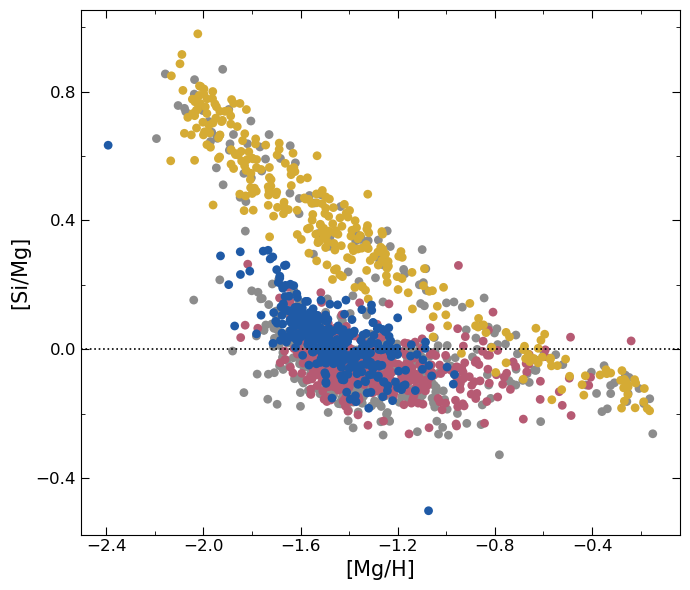

In [12]:
omega_plot_df = prepare_omega_background(data)

fig, ax = plt.subplots(figsize=(7, 6))
plot_omega_background(ax, omega_plot_df)

#legend = ax.legend(frameon=True, fontsize=12, loc="upper right")
#legend.get_frame().set_edgecolor("black")
#legend.get_frame().set_linewidth(1.2)

plt.tight_layout()

plt.savefig("w_cen_SI_MG_simple", dpi=300, bbox_inches="tight")

plt.show()


Overlay comparison using Omega Cen (N=1755)

Plotting Type 1 clusters (>=10 stars)


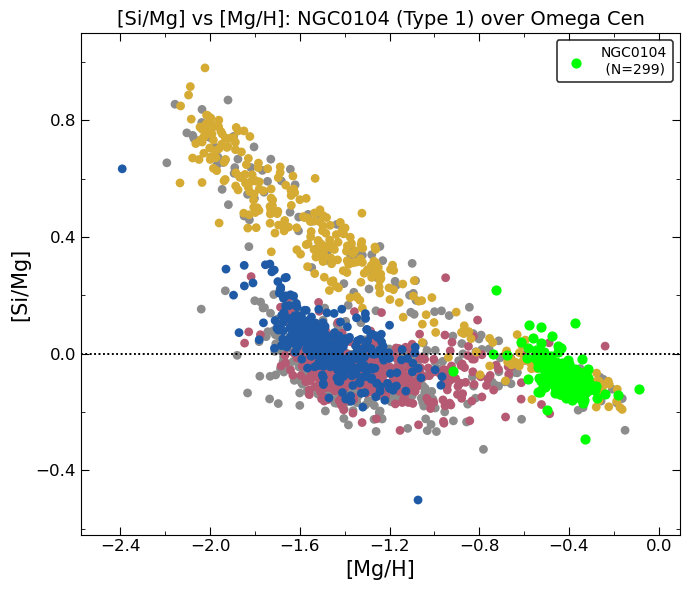

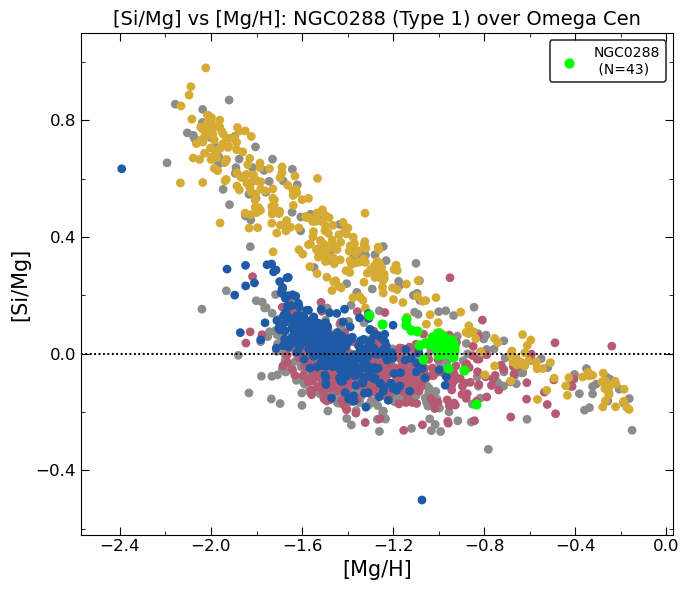

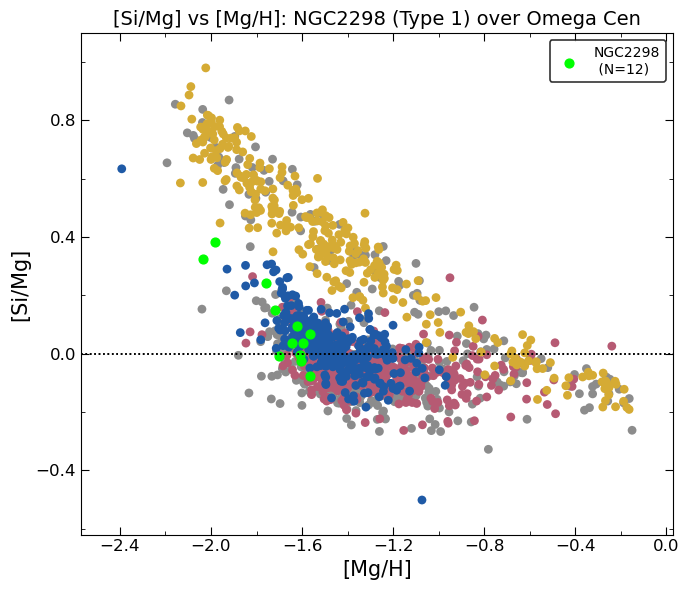

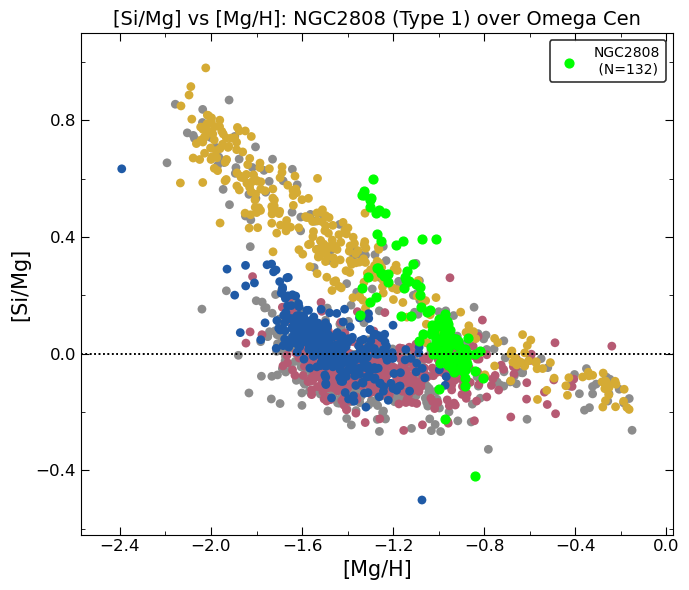

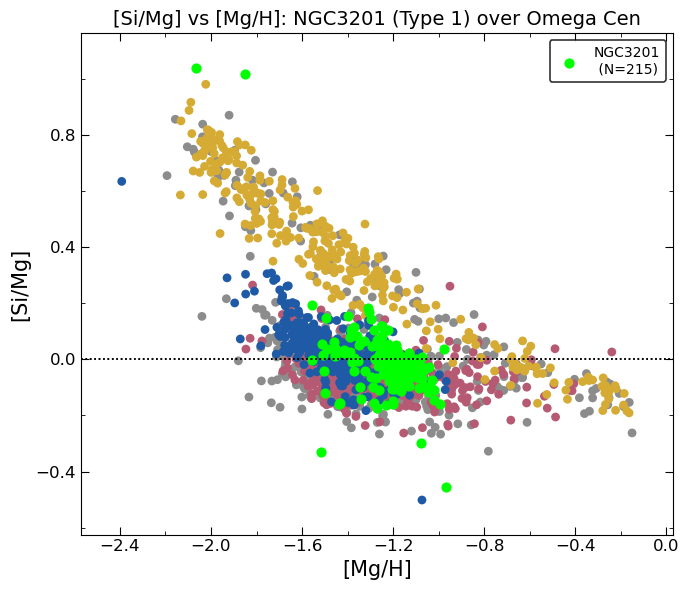

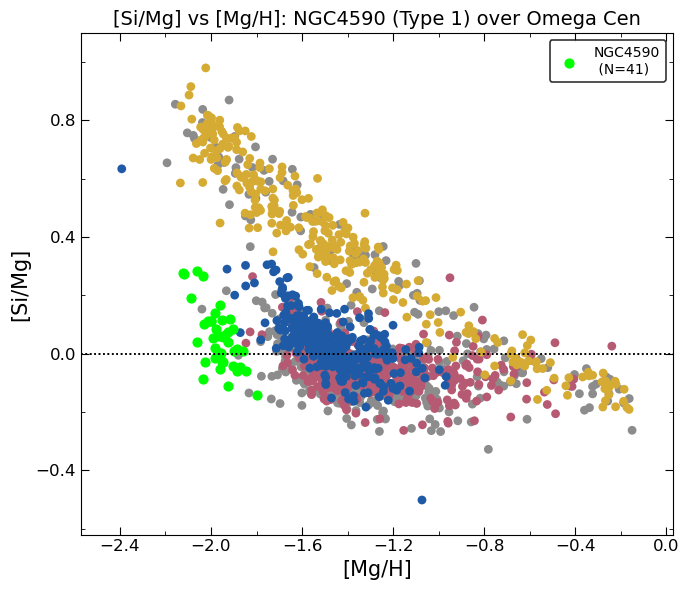

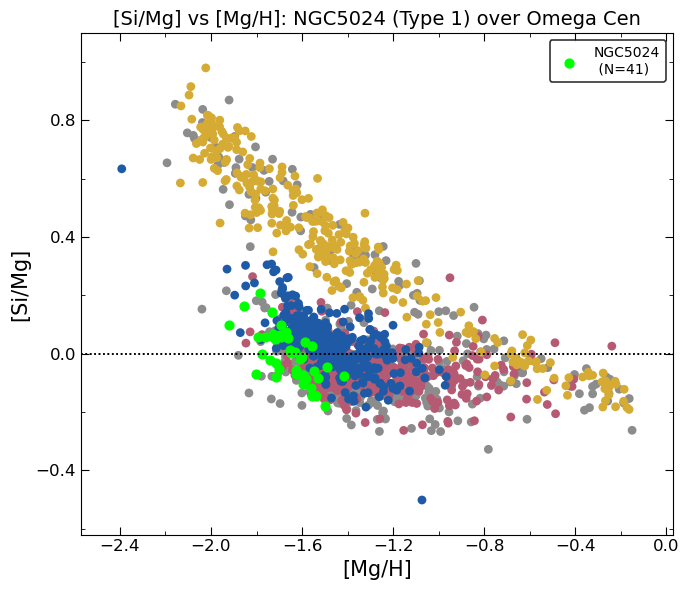

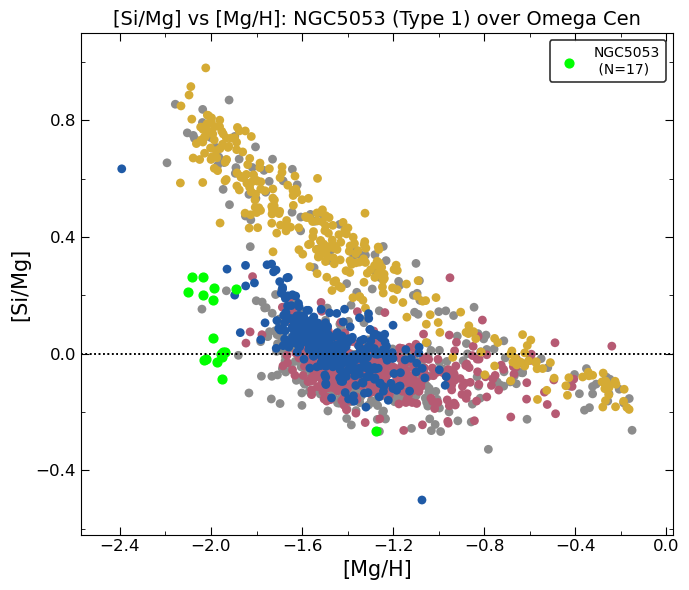

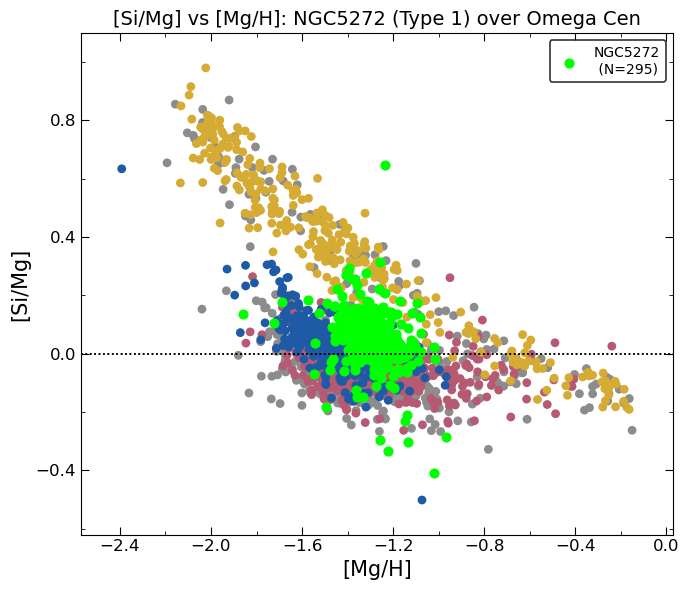

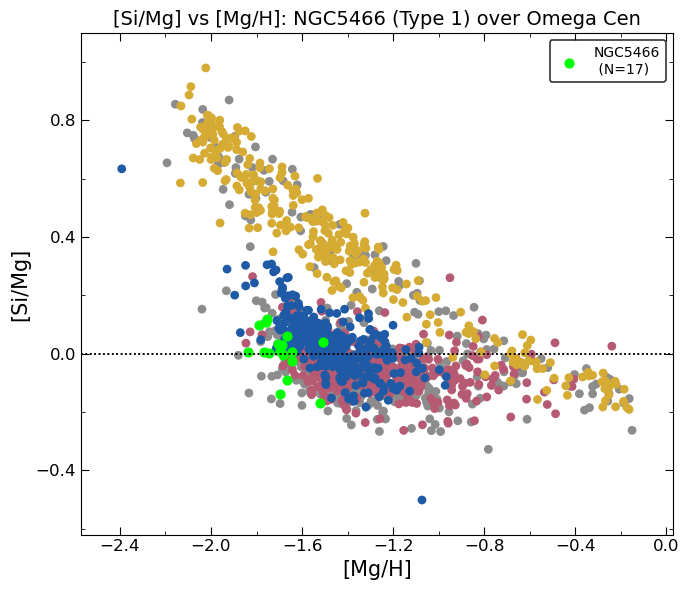

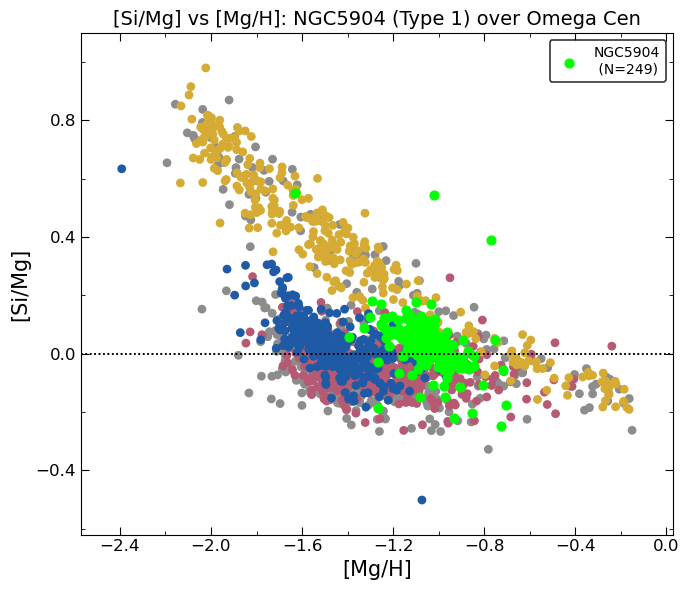

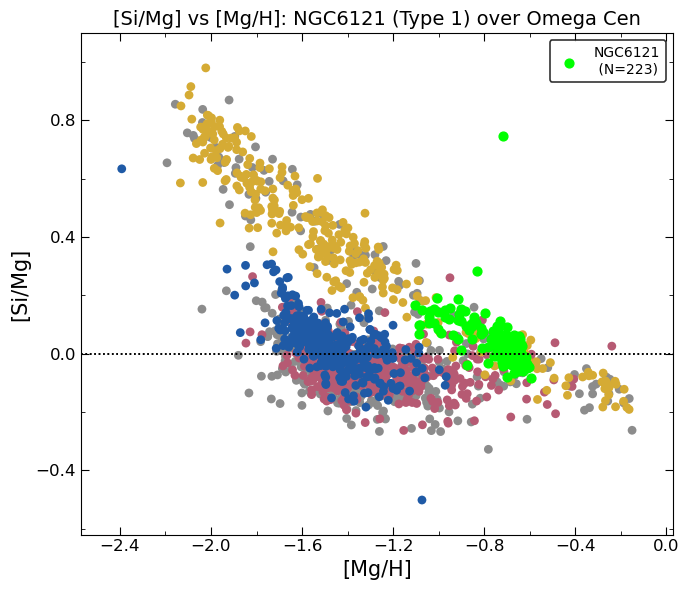

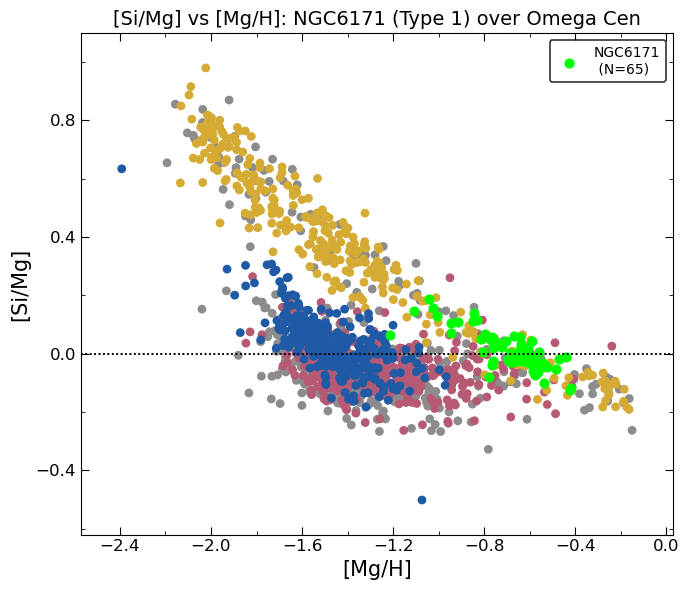

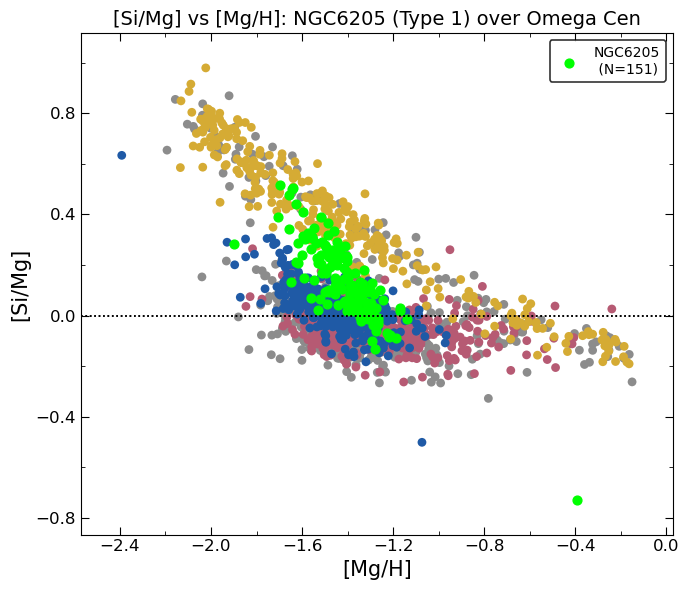

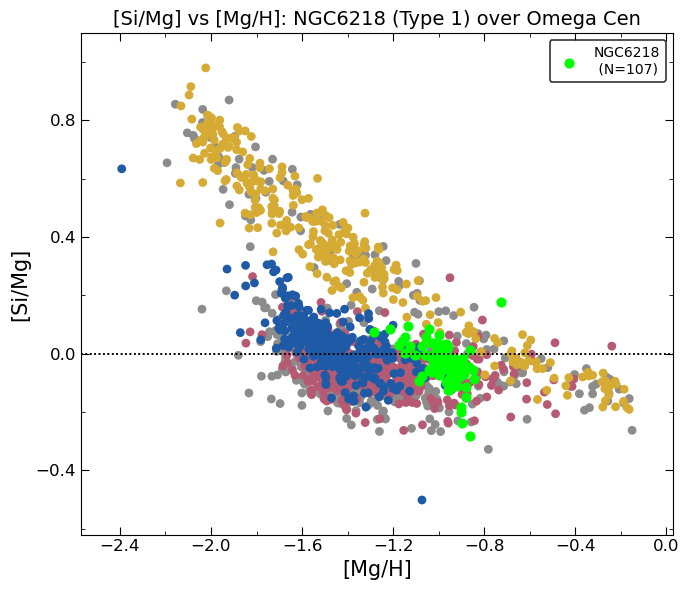

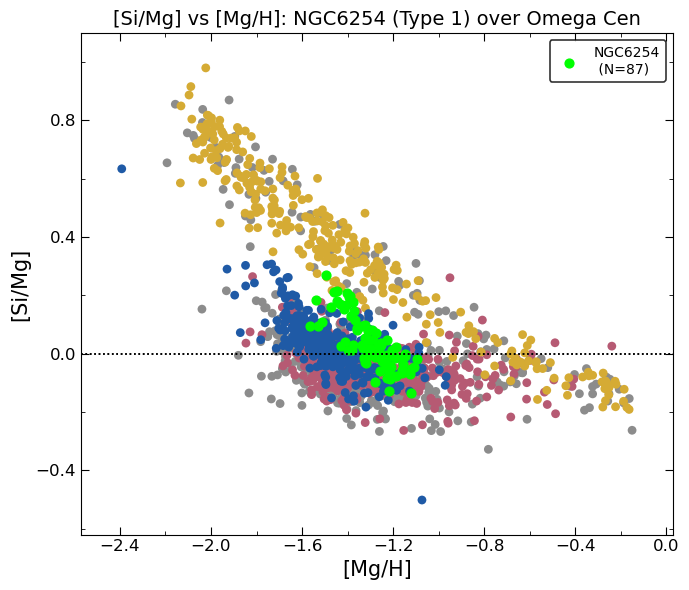

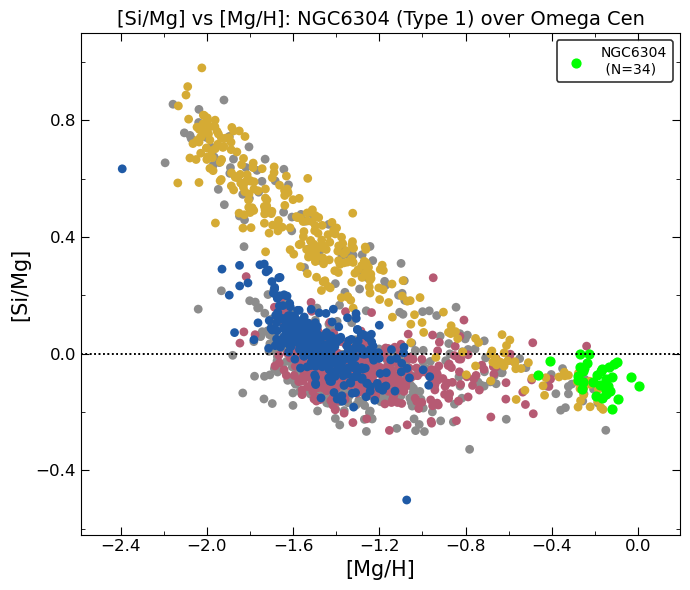

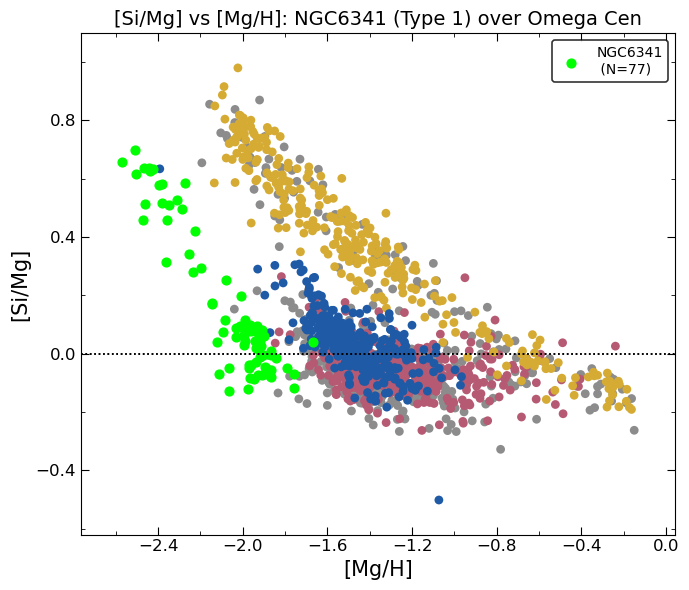

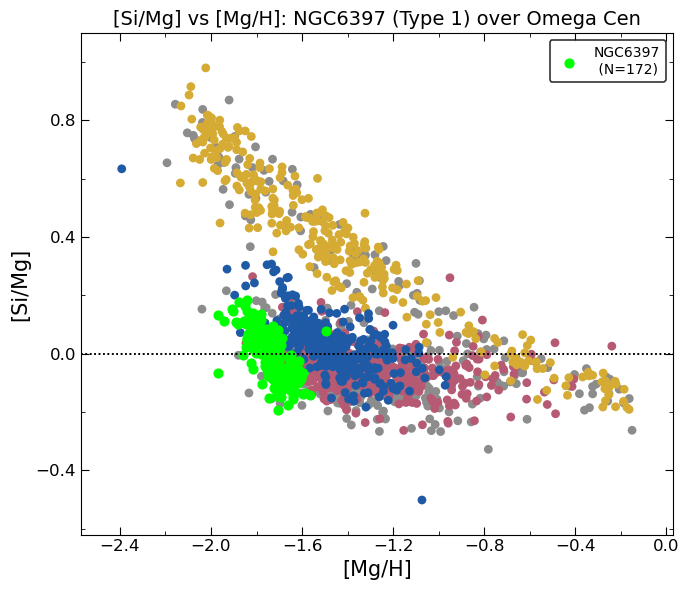

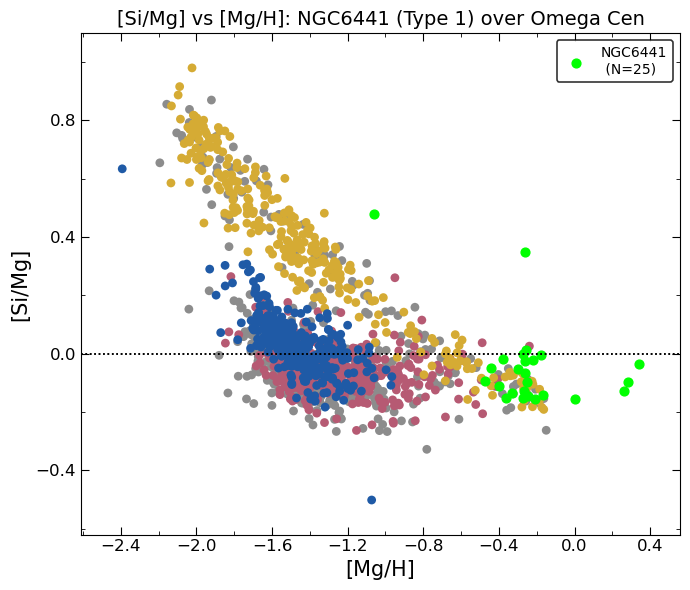

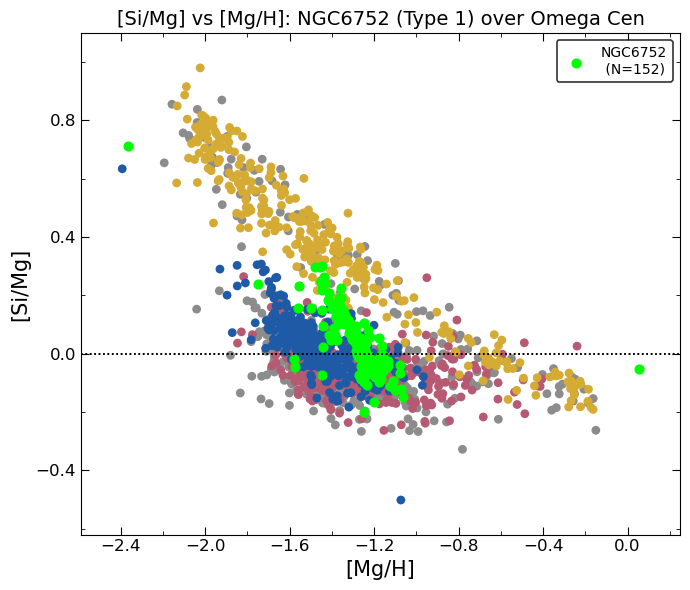

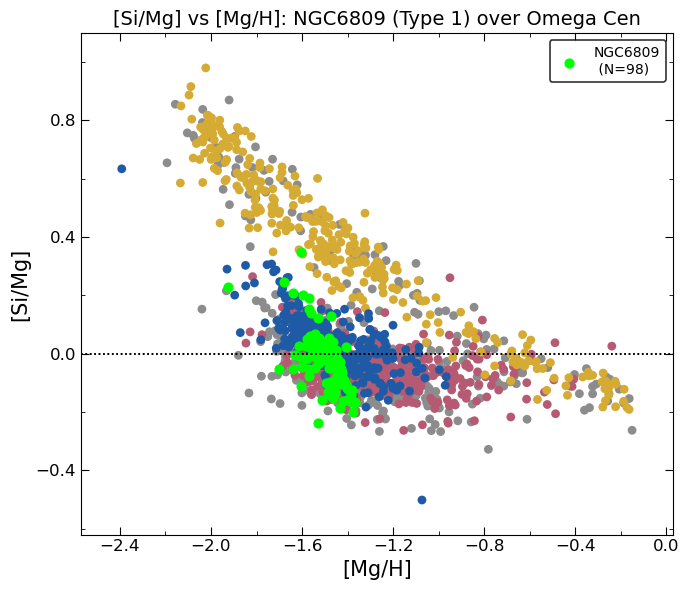

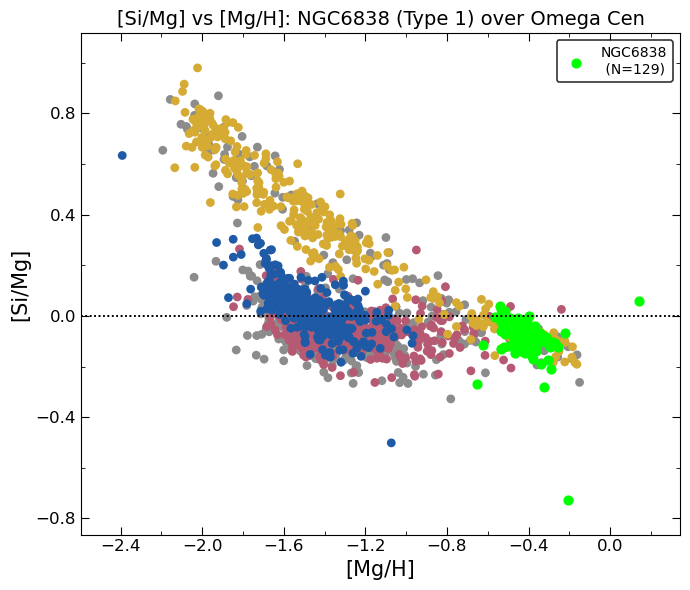

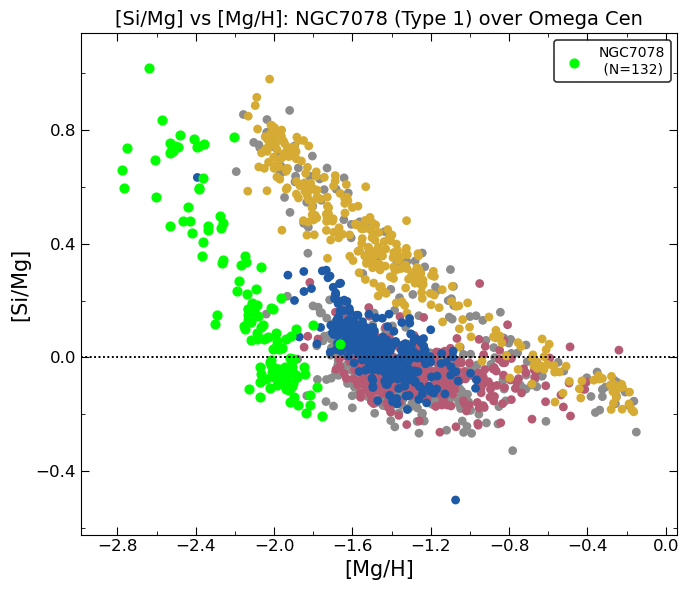


Plotting Type 2 clusters (>=10 stars)


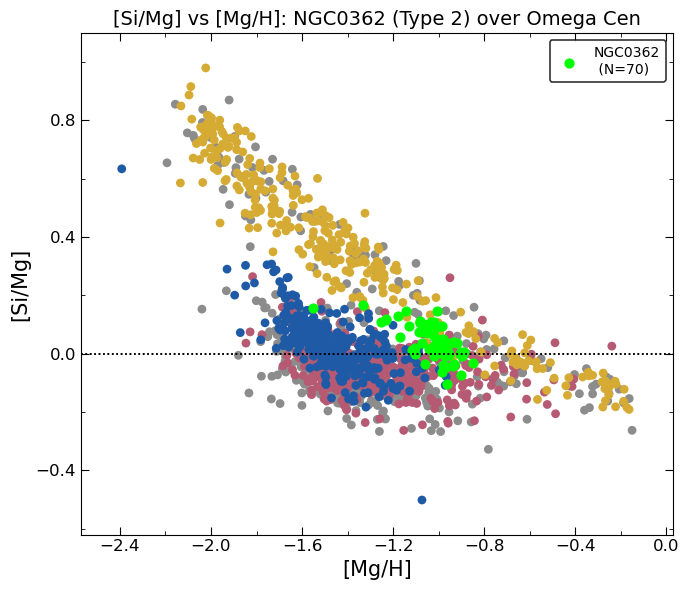

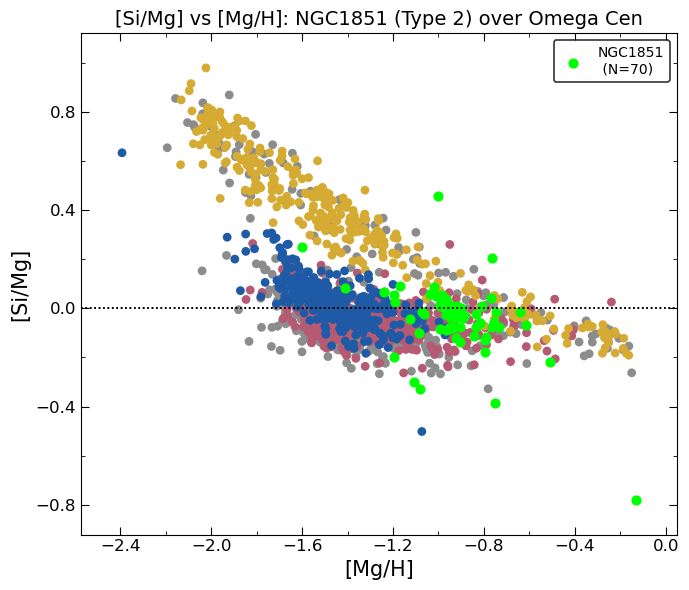

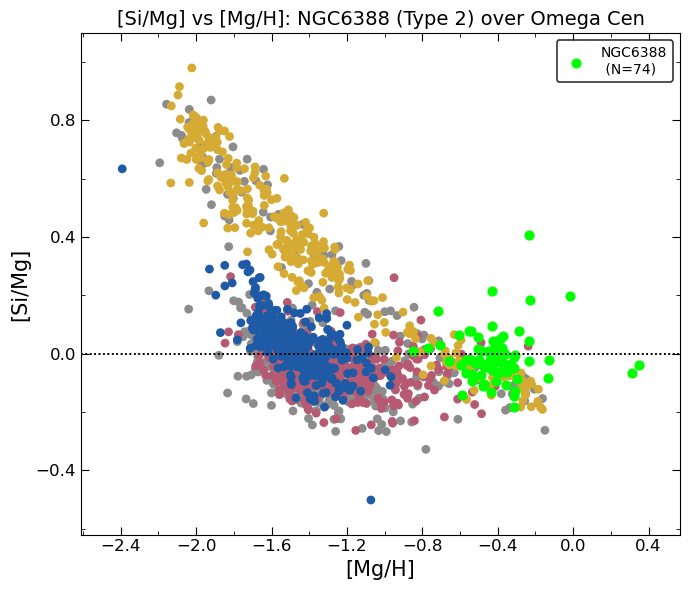

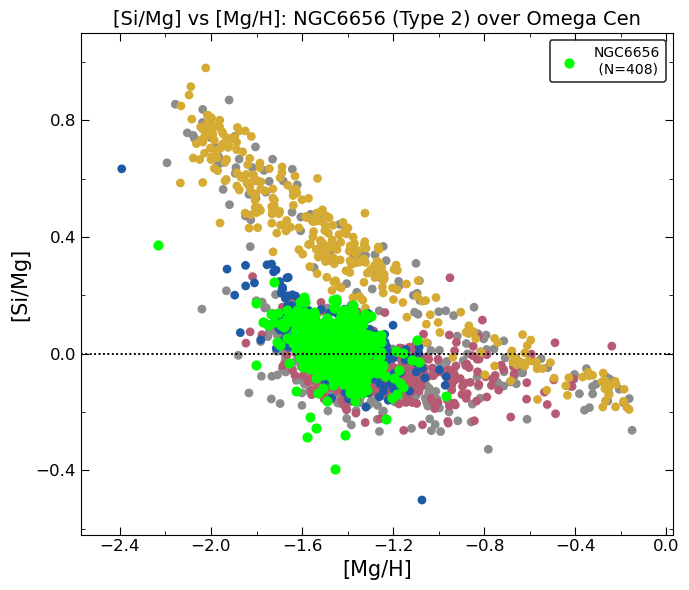

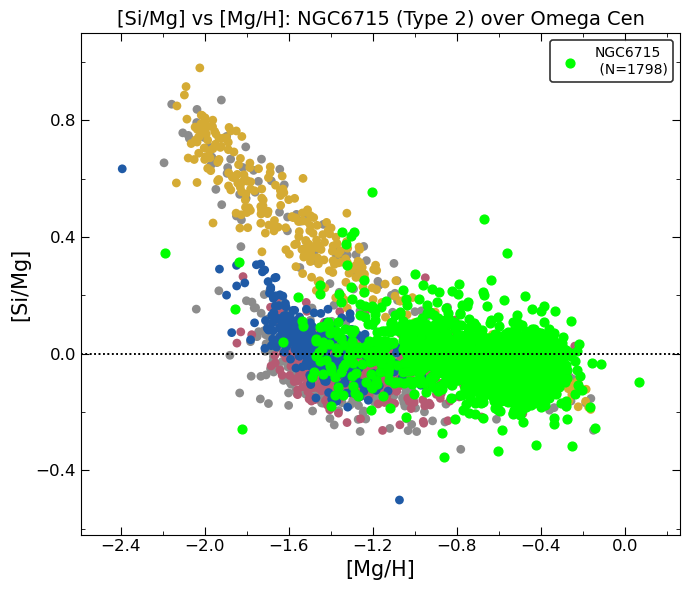

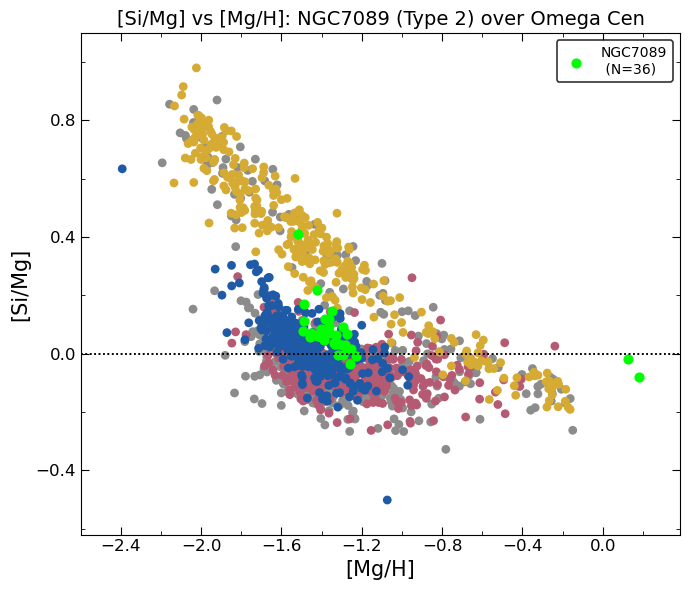


Plotting Unidentified clusters (>=10 stars)


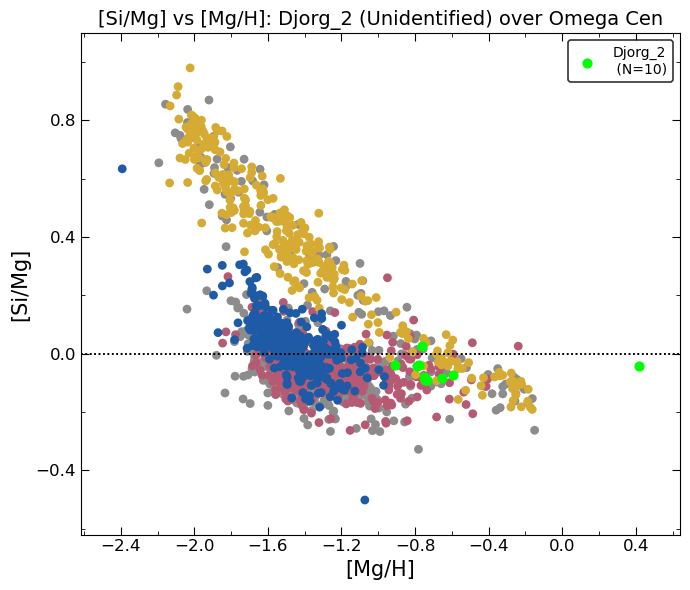

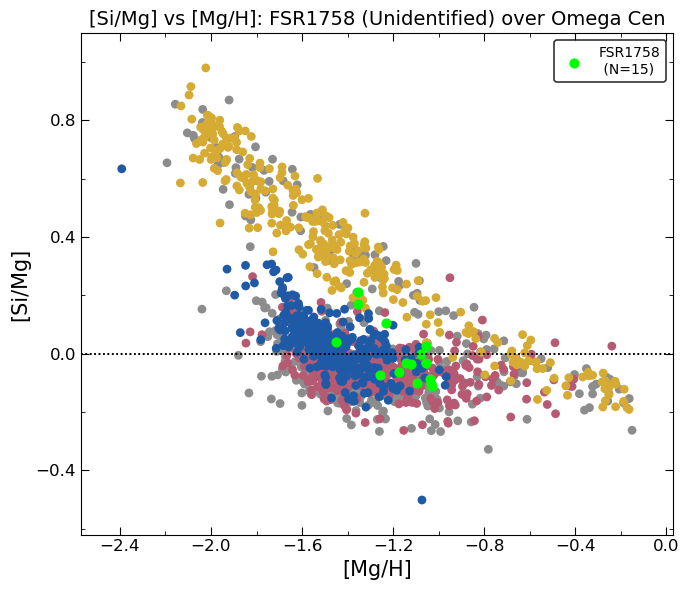

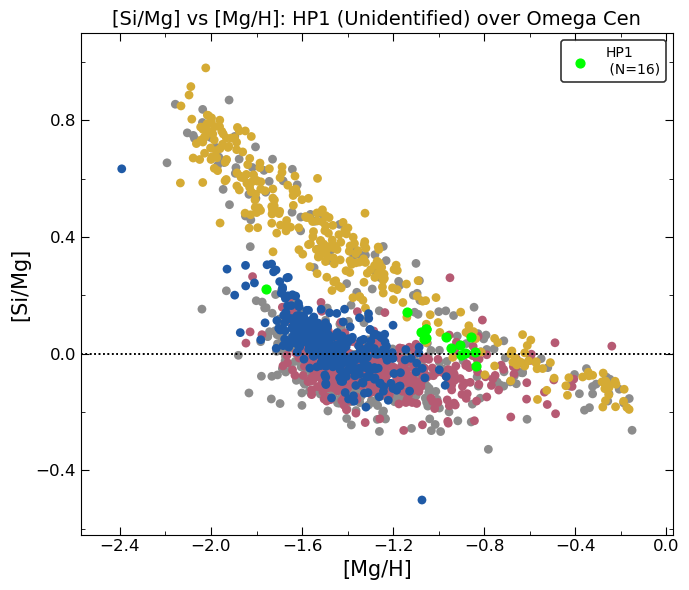

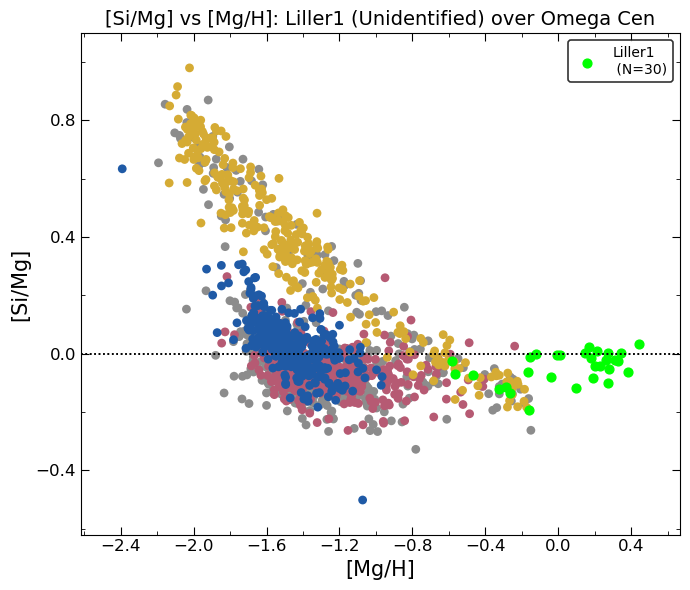

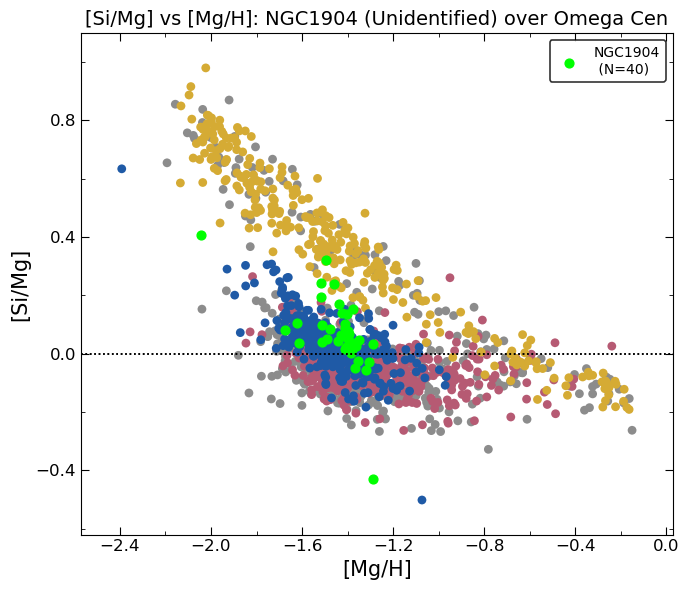

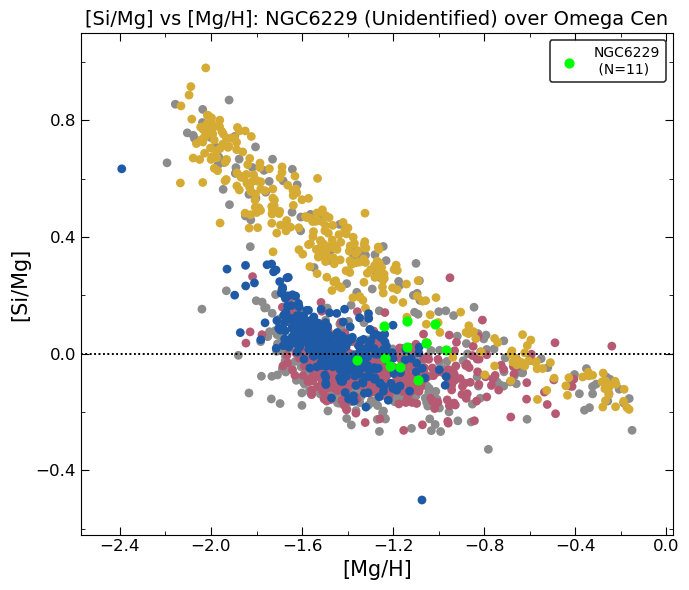

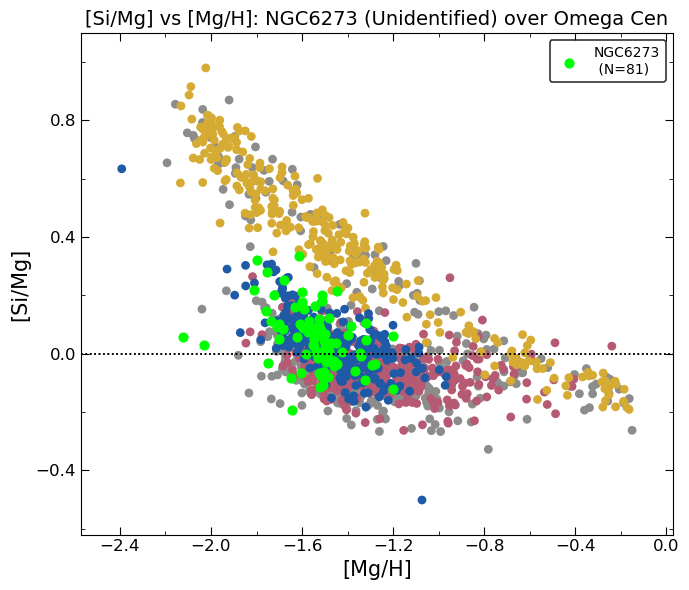

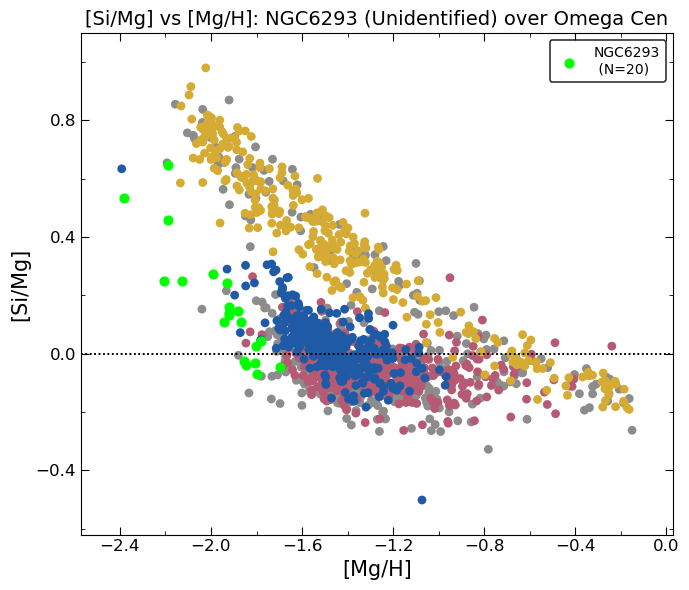

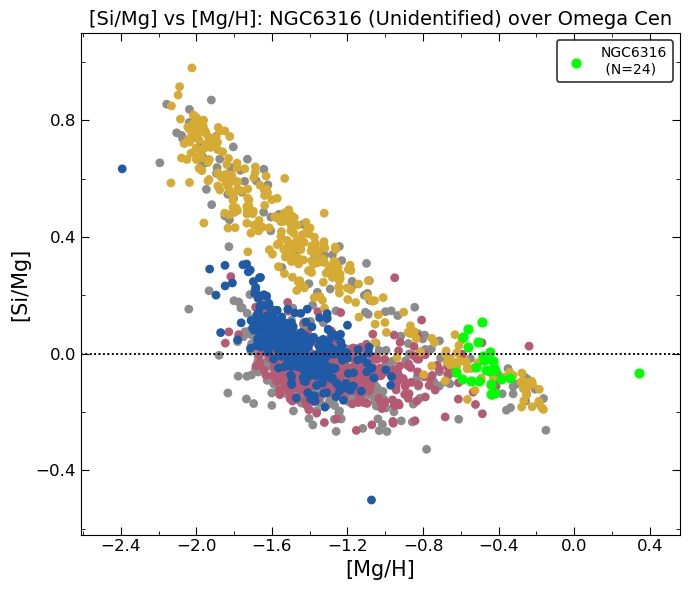

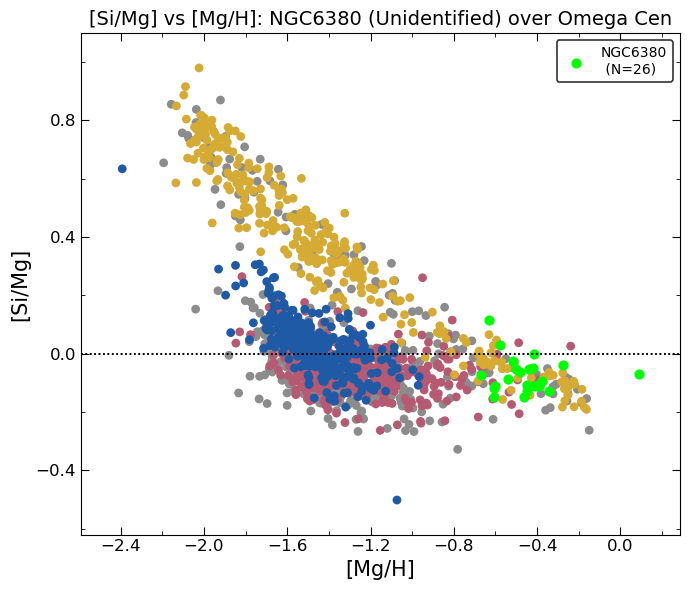

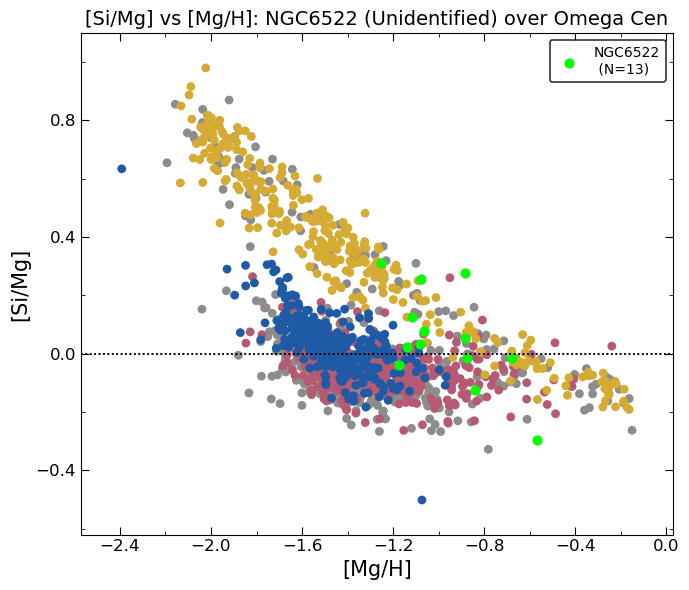

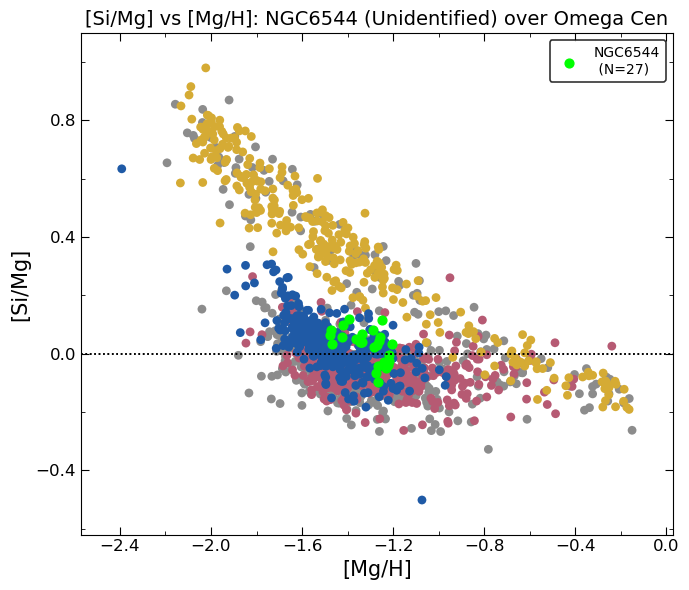

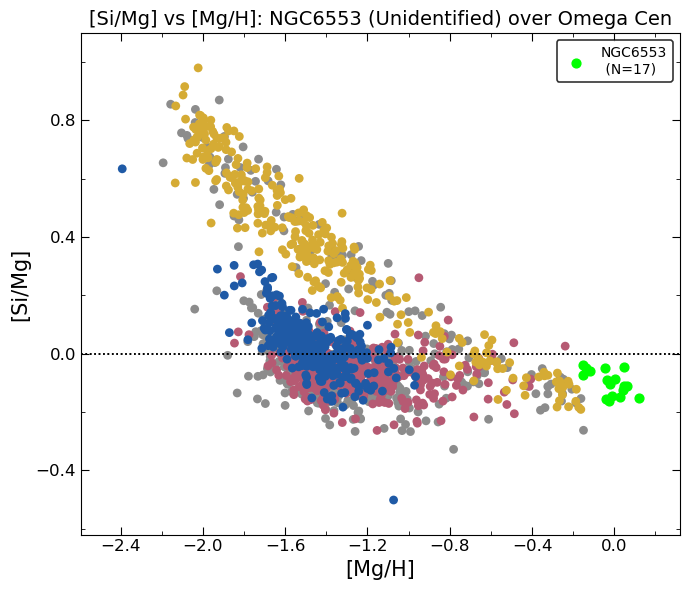

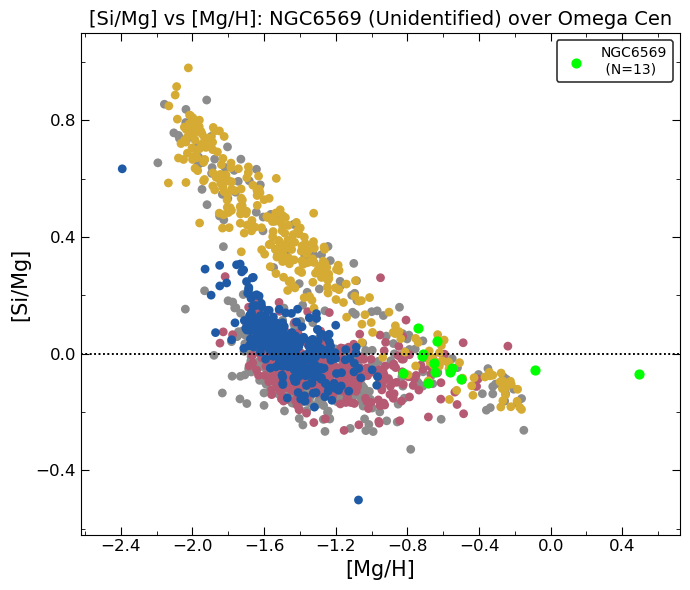

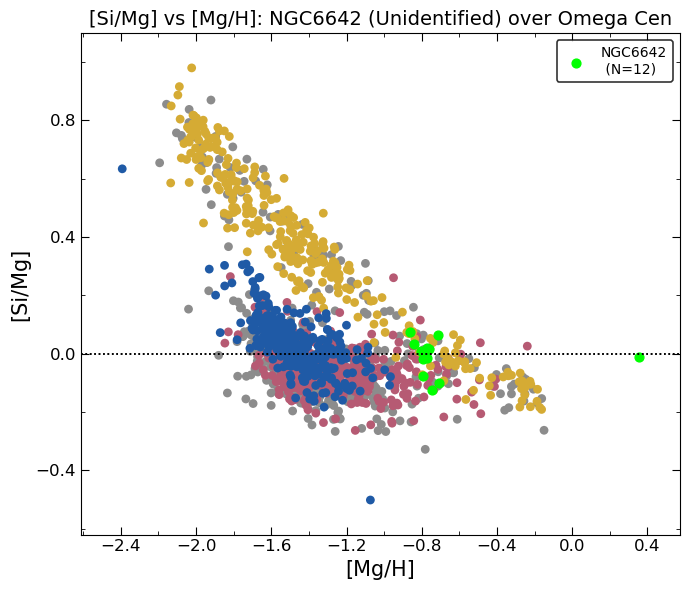

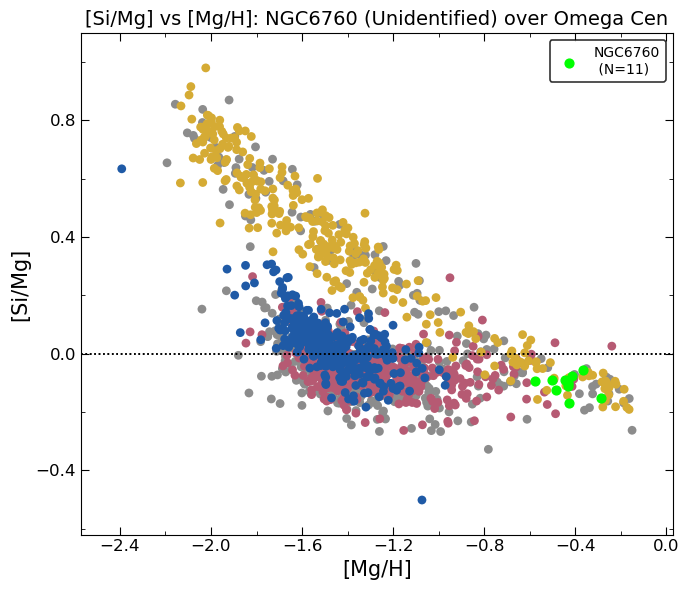

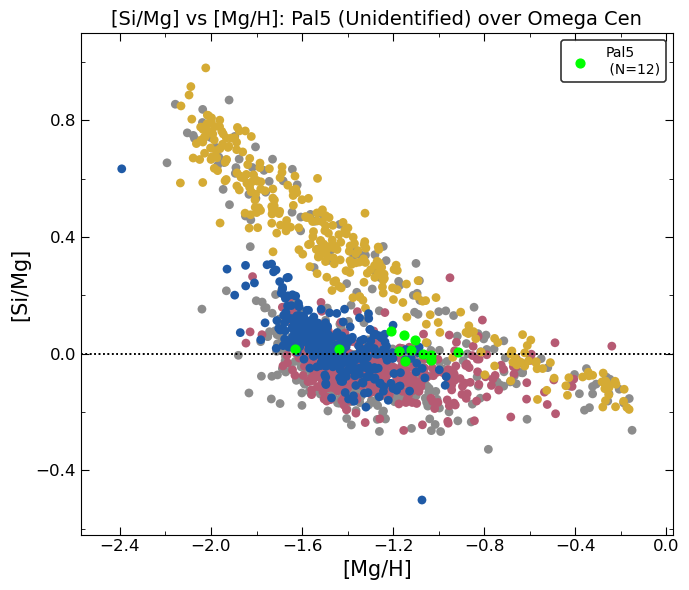

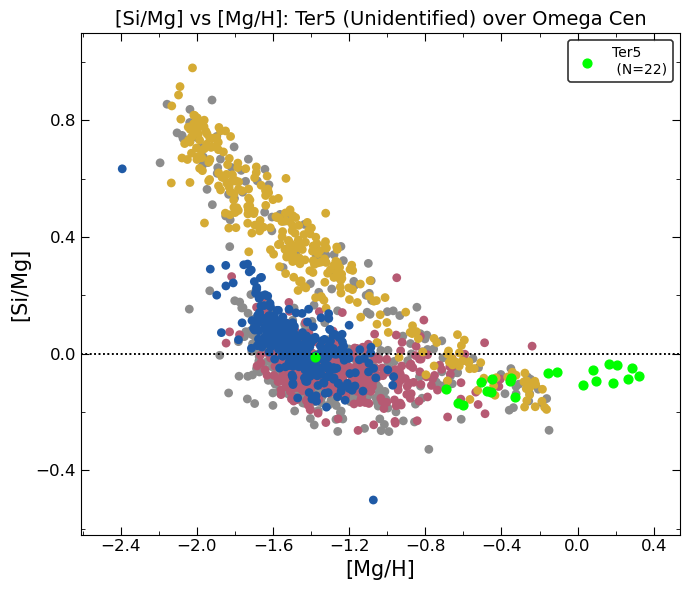

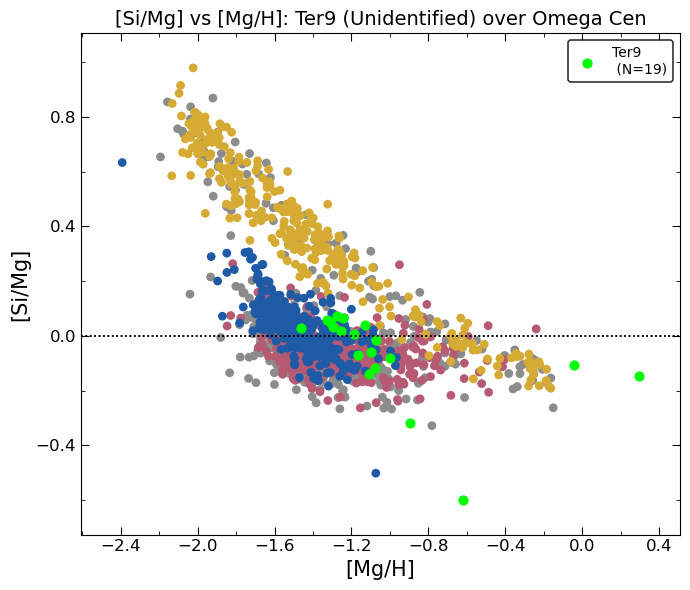

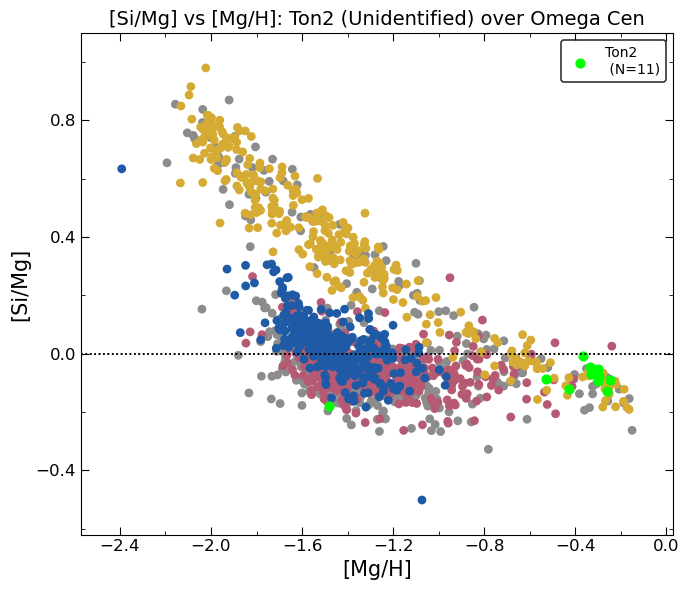

In [16]:
unique_clusters, counts = np.unique(gc_names, return_counts=True)
valid_clusters = unique_clusters[counts >= 10]

omega_plot_df = prepare_omega_background(data)

bg_colors = {
    "Unlabeled": "#8c8c8c",
    "P1": "#b65a73",
    "P2": "#d5ab34",
    "IM": "#1f5aa6"
}

bg_sizes = {
    "Unlabeled": 40,
    "P1": 40,
    "P2": 40,
    "IM": 40
}

type_labels = ["Type 1", "Type 2", "Unidentified"]

print(f"\nOverlay comparison using Omega Cen (N={omega_plot_df.shape[0]})")

for cluster_type in type_labels:

    print(f"\nPlotting {cluster_type} clusters (>=10 stars)")

    for cluster_name in valid_clusters:

        if cluster_name == omega_name:
            continue

        if cluster_type_map[cluster_name] != cluster_type:
            continue

        cluster_mask = (gc_names == cluster_name)
        N_cluster = np.sum(cluster_mask)

        if N_cluster < 10:
            continue

        cluster_Mg_H = data["MG_FE"][cluster_mask] + data["FE_H"][cluster_mask]
        cluster_Si_Mg = data["SI_FE"][cluster_mask] - data["MG_FE"][cluster_mask]

        finite = np.isfinite(cluster_Mg_H) & np.isfinite(cluster_Si_Mg)
        cluster_Mg_H = cluster_Mg_H[finite]
        cluster_Si_Mg = cluster_Si_Mg[finite]

        fig, ax = plt.subplots(figsize=(7, 6))

        plot_omega_background(ax, omega_plot_df, show_labels=False)

        ax.scatter(
            cluster_Mg_H,
            cluster_Si_Mg,
            s=40,
            color="lime",
            alpha=1.0,
            label=f"{cluster_name}\n (N={len(cluster_Mg_H)})"
        )

        ax.axhline(0.0, color="black", linestyle=":", linewidth=1.2)

        ax.set_xlabel("[Mg/H]", fontsize=15)
        ax.set_ylabel("[Si/Mg]", fontsize=15)
        x_all = np.concatenate([omega_plot_df["MG_H"].values, np.asarray(cluster_Mg_H)])
        y_all = np.concatenate([omega_plot_df["SI_MG"].values, np.asarray(cluster_Si_Mg)])

        x_min, x_max = np.nanmin(x_all), np.nanmax(x_all)
        y_min, y_max = np.nanmin(y_all), np.nanmax(y_all)

        x_pad = max(0.08, 0.08 * (x_max - x_min))
        y_pad = max(0.08, 0.08 * (y_max - y_min))

        ax.set_xlim(x_min - x_pad, x_max + x_pad)
        ax.set_ylim(y_min - y_pad, y_max + y_pad)

        ax.xaxis.set_major_locator(MultipleLocator(0.4))
        ax.yaxis.set_major_locator(MultipleLocator(0.4))
        ax.xaxis.set_minor_locator(MultipleLocator(0.2))
        ax.yaxis.set_minor_locator(MultipleLocator(0.2))

        ax.tick_params(axis="both", which="major", labelsize=12, direction="in", top=True, right=True, length=6)
        ax.tick_params(axis="both", which="minor", direction="in", top=True, right=True, length=3)

        ax.set_title(
            f"[Si/Mg] vs [Mg/H]: {cluster_name} ({cluster_type}) over Omega Cen",
            fontsize=14
        )

        legend = ax.legend(frameon=True, fontsize=10, loc="upper right")
        legend.get_frame().set_edgecolor("black")
        legend.get_frame().set_linewidth(1.2)
        plt.tight_layout()

        output_dir = os.path.join("cluster_plots_Si_Mg", "ge_10")
        os.makedirs(output_dir, exist_ok=True)

        filename = f"{cluster_type}_{cluster_name}_N{N_cluster}.png".replace(" ", "_")
        plt.savefig(os.path.join(output_dir, filename), dpi=300, bbox_inches="tight")

        plt.show()

In [17]:
gc_names = data["GC_NAME"]

unique_clusters, counts = np.unique(gc_names, return_counts=True)

n_clusters_10plus = np.sum(counts >= 10)

print(f"Number of clusters in the VAC with ≥10 stars: {n_clusters_10plus}")

Number of clusters in the VAC with ≥10 stars: 51



Overlay comparison using Omega Cen (N=1755)

Plotting Type 1 clusters (<10 stars)


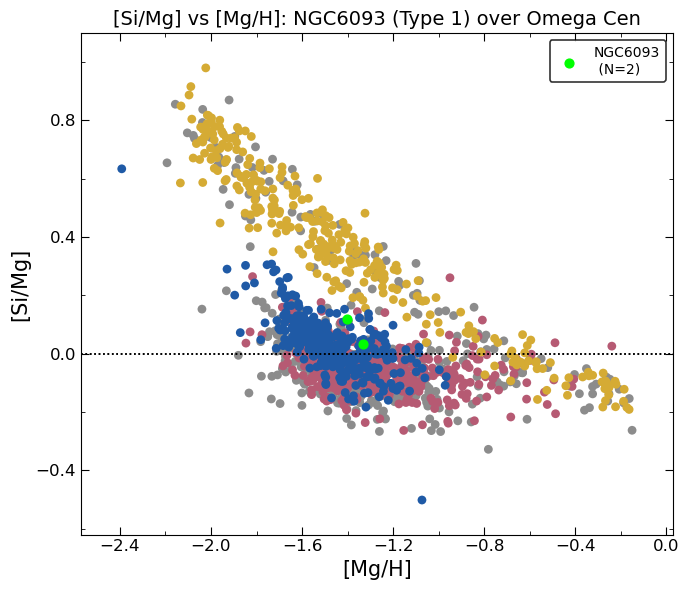

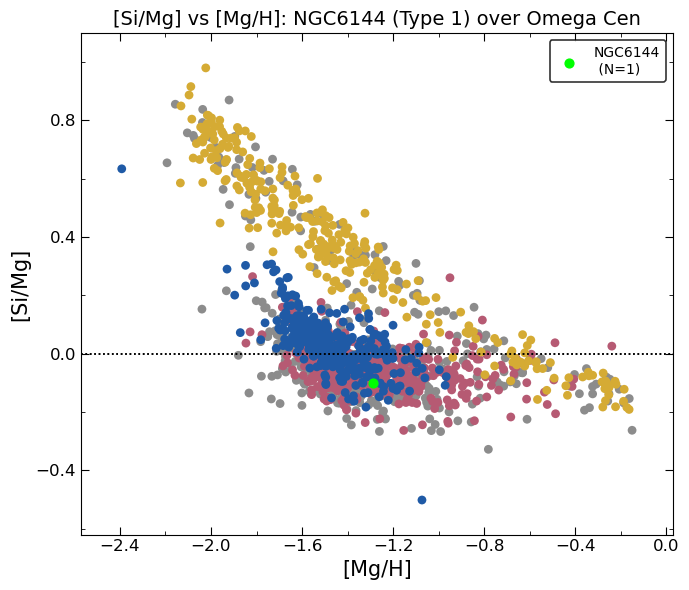

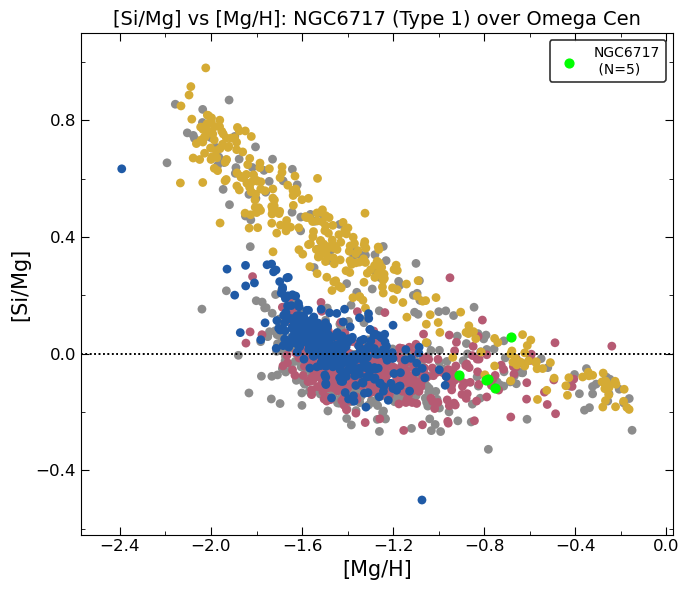

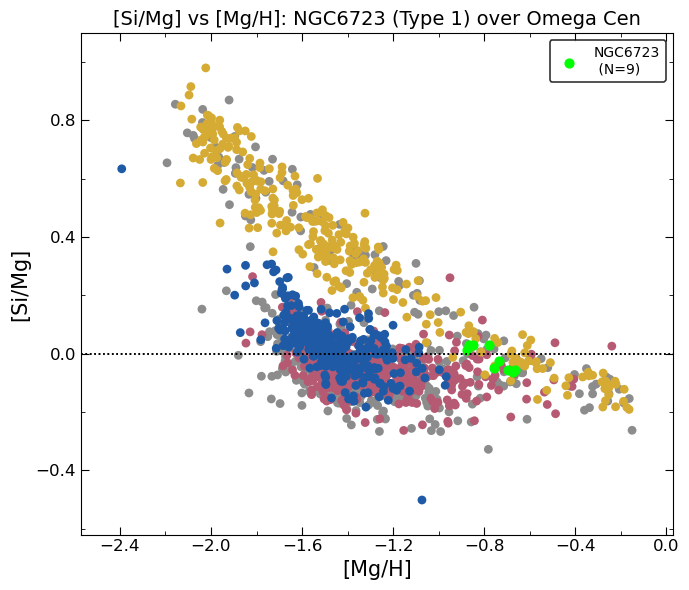


Plotting Type 2 clusters (<10 stars)
N/A (no clusters in this category)

Plotting Unidentified clusters (<10 stars)


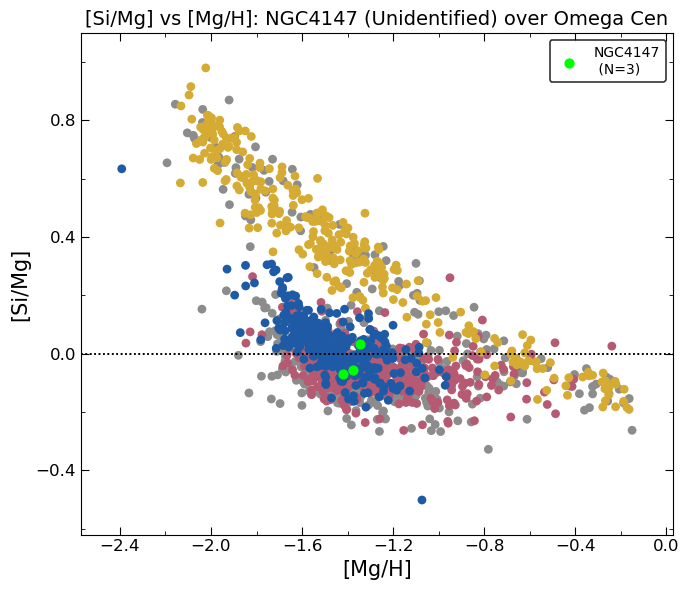

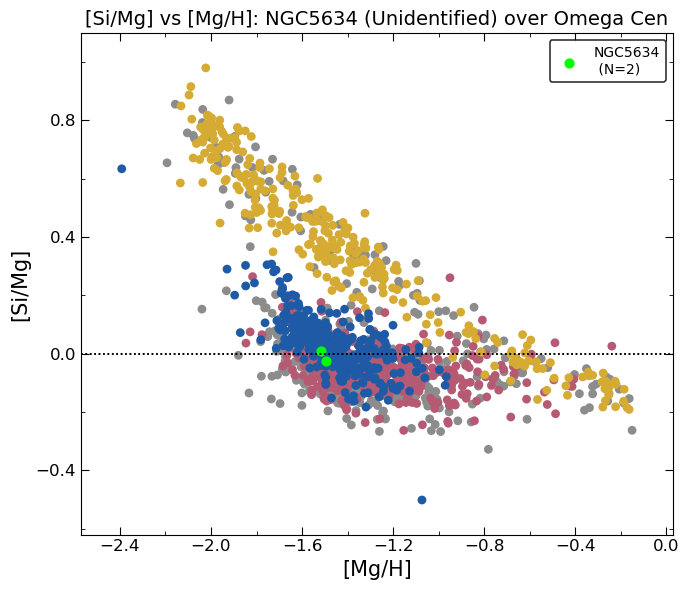

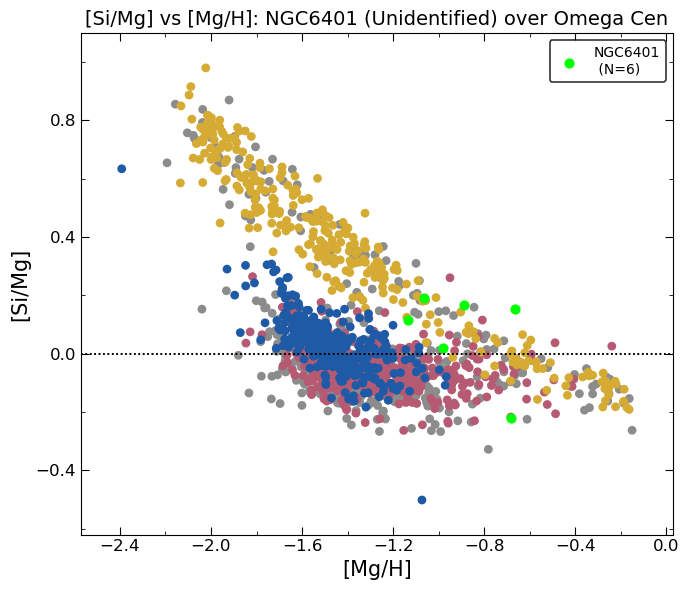

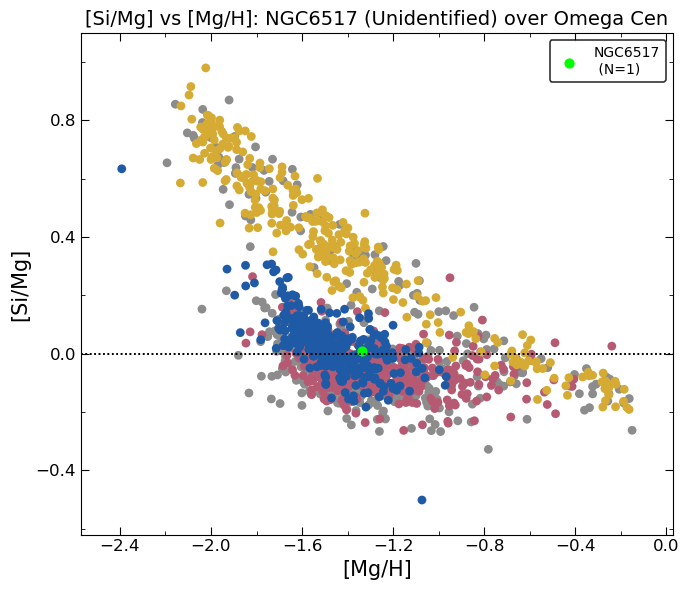

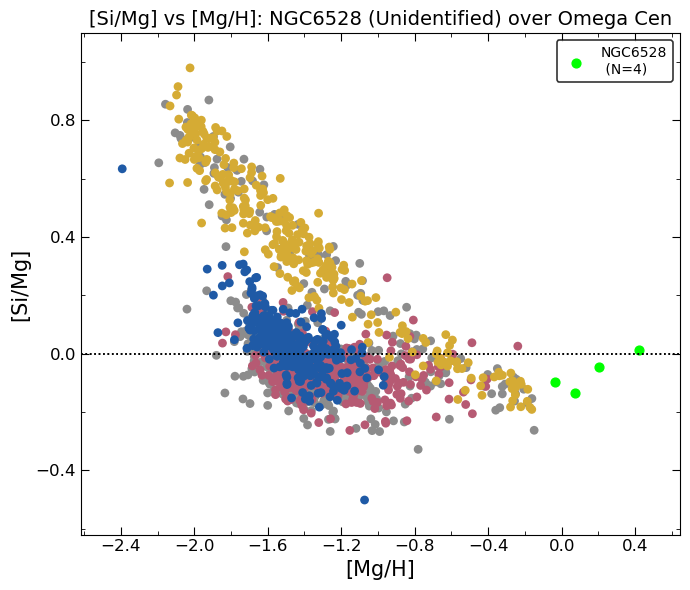

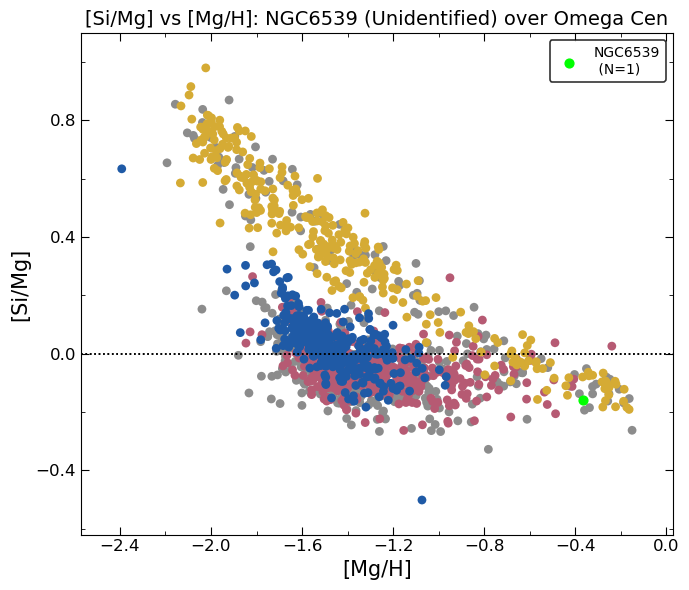

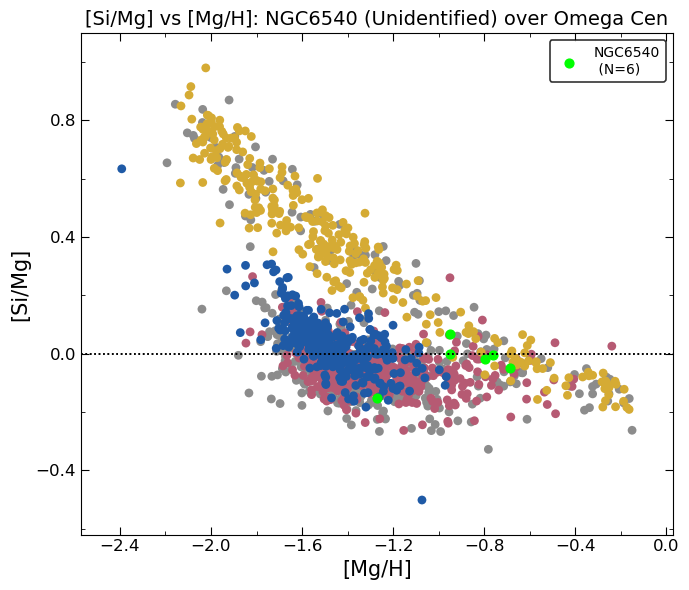

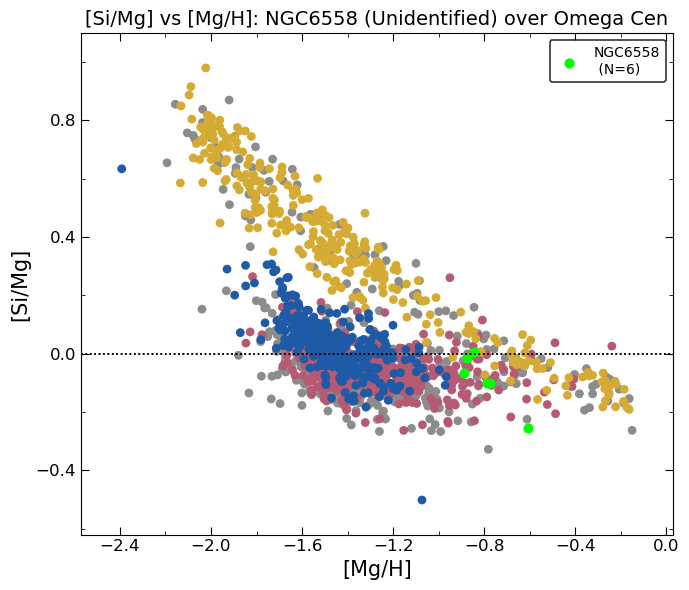

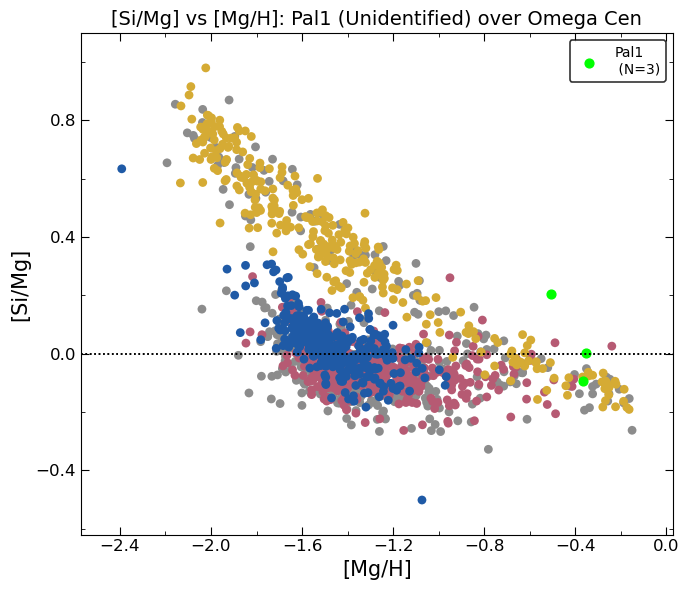

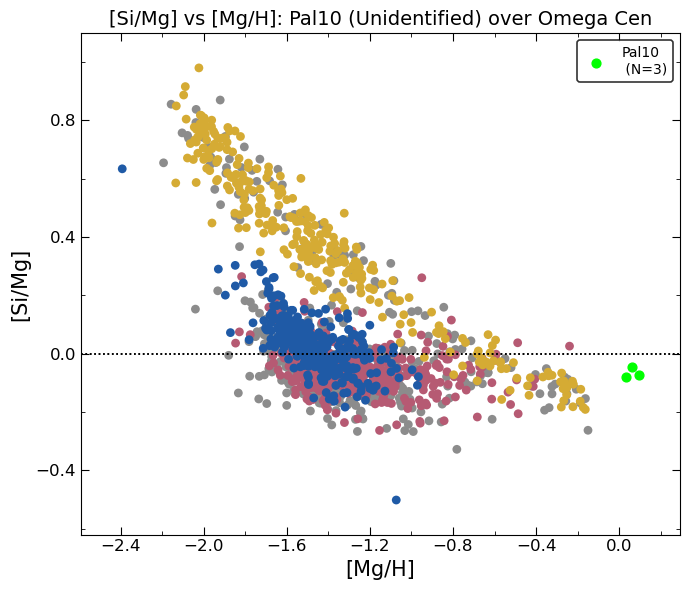

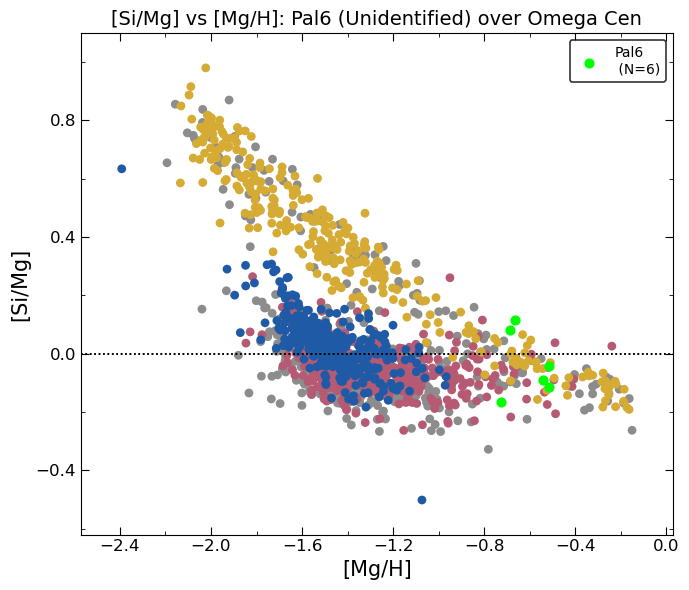

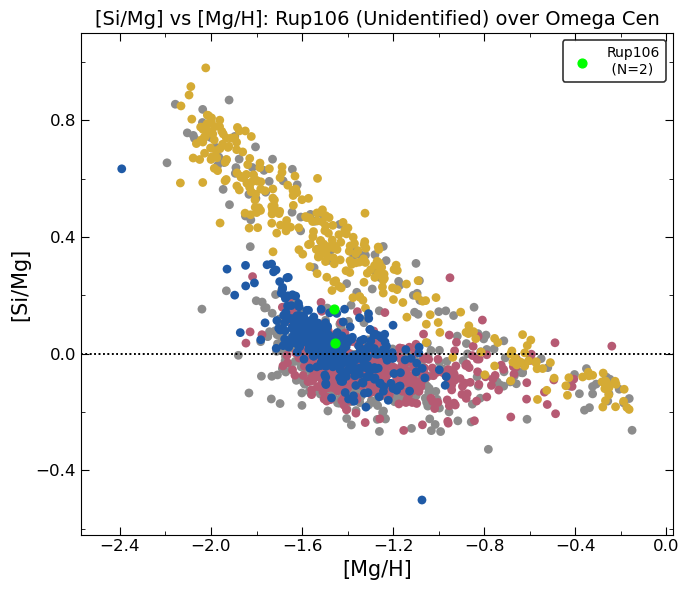

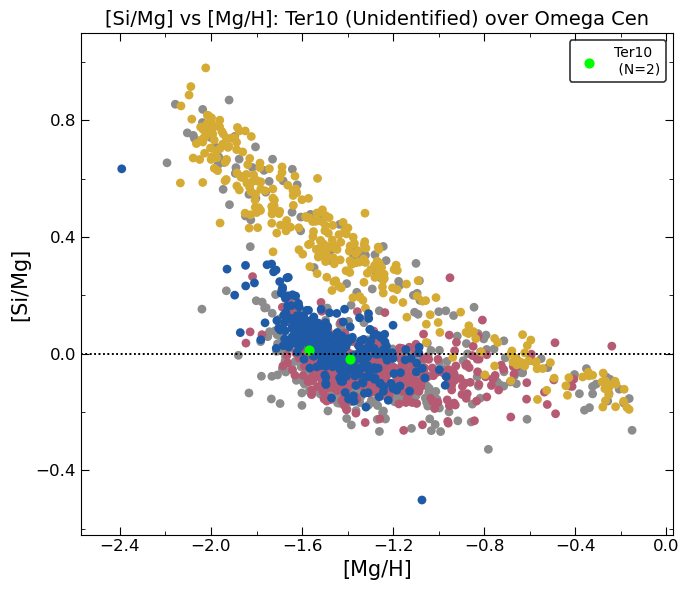

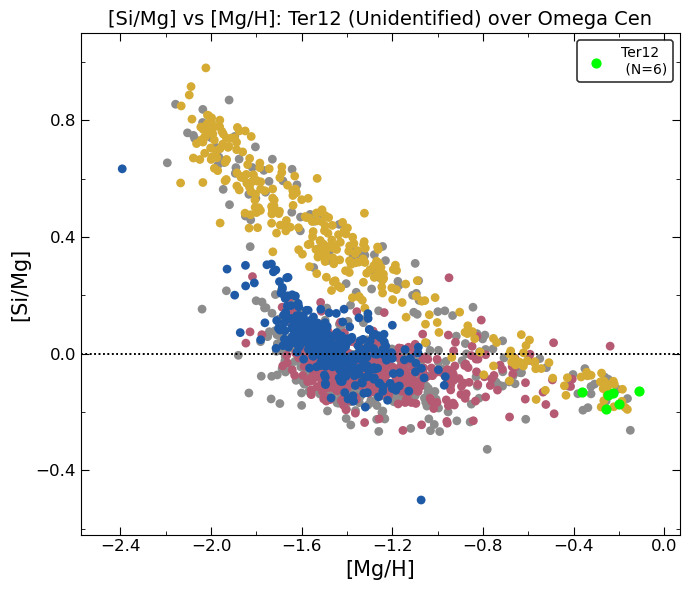

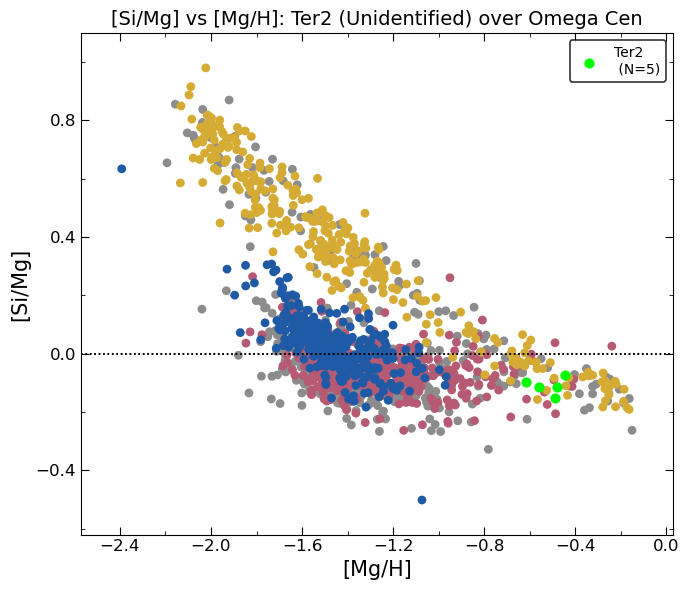

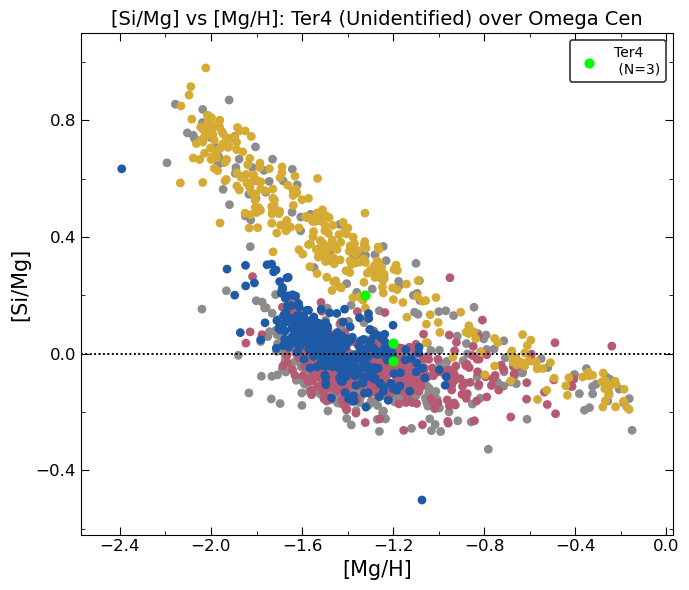

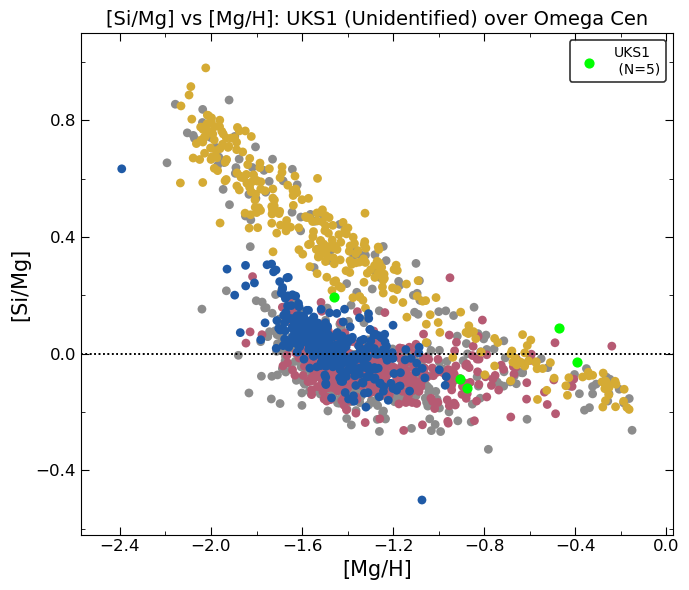

In [18]:
unique_clusters, counts = np.unique(gc_names, return_counts=True)
valid_clusters = unique_clusters[counts < 10]

omega_plot_df = prepare_omega_background(data)

bg_colors = {
    "Unlabeled": "#8c8c8c",
    "P1": "#b65a73",
    "P2": "#d5ab34",
    "IM": "#1f5aa6"
}

bg_sizes = {
    "Unlabeled": 40,
    "P1": 40,
    "P2": 40,
    "IM": 40
}

type_labels = ["Type 1", "Type 2", "Unidentified"]

print(f"\nOverlay comparison using Omega Cen (N={omega_plot_df.shape[0]})")

for cluster_type in type_labels:

    print(f"\nPlotting {cluster_type} clusters (<10 stars)")

    type_clusters = [
        name for name in valid_clusters
        if name != omega_name and cluster_type_map[name] == cluster_type
    ]

    if len(type_clusters) == 0:
        print("N/A (no clusters in this category)")
        continue

    for cluster_name in type_clusters:

        cluster_mask = (gc_names == cluster_name)
        cluster_Mg_H = data["MG_FE"][cluster_mask] + data["FE_H"][cluster_mask]
        cluster_Si_Mg = data["SI_FE"][cluster_mask] - data["MG_FE"][cluster_mask]

        finite = np.isfinite(cluster_Mg_H) & np.isfinite(cluster_Si_Mg)
        cluster_Mg_H = cluster_Mg_H[finite]
        cluster_Si_Mg = cluster_Si_Mg[finite]
        N_cluster = len(cluster_Mg_H)

        fig, ax = plt.subplots(figsize=(7, 6))

        plot_omega_background(ax, omega_plot_df, show_labels=False)

        ax.scatter(
            cluster_Mg_H,
            cluster_Si_Mg,
            s=40,
            color="lime",
            alpha=1.0,
            label=f"{cluster_name}\n (N={N_cluster})"
        )

        ax.axhline(0.0, color="black", linestyle=":", linewidth=1.2)

        ax.set_xlabel("[Mg/H]", fontsize=15)
        ax.set_ylabel("[Si/Mg]", fontsize=15)
        x_all = np.concatenate([omega_plot_df["MG_H"].values, np.asarray(cluster_Mg_H)])
        y_all = np.concatenate([omega_plot_df["SI_MG"].values, np.asarray(cluster_Si_Mg)])

        x_min, x_max = np.nanmin(x_all), np.nanmax(x_all)
        y_min, y_max = np.nanmin(y_all), np.nanmax(y_all)

        x_pad = max(0.08, 0.08 * (x_max - x_min))
        y_pad = max(0.08, 0.08 * (y_max - y_min))

        ax.set_xlim(x_min - x_pad, x_max + x_pad)
        ax.set_ylim(y_min - y_pad, y_max + y_pad)

        ax.xaxis.set_major_locator(MultipleLocator(0.4))
        ax.yaxis.set_major_locator(MultipleLocator(0.4))
        ax.xaxis.set_minor_locator(MultipleLocator(0.2))
        ax.yaxis.set_minor_locator(MultipleLocator(0.2))


        ax.tick_params(axis="both", which="major", labelsize=12, direction="in", top=True, right=True, length=6)
        ax.tick_params(axis="both", which="minor", direction="in", top=True, right=True, length=3)

        ax.set_title(
            f"[Si/Mg] vs [Mg/H]: {cluster_name} ({cluster_type}) over Omega Cen",
            fontsize=14
        )

        legend = ax.legend(frameon=True, fontsize=10, loc="upper right")
        legend.get_frame().set_edgecolor("black")
        legend.get_frame().set_linewidth(1.2)
        plt.tight_layout()

        output_dir = os.path.join("cluster_plots_Si_Mg", "lt_10")
        os.makedirs(output_dir, exist_ok=True)

        filename = f"{cluster_type}_{cluster_name}_N{N_cluster}.png".replace(" ", "_")
        plt.savefig(os.path.join(output_dir, filename), dpi=300, bbox_inches="tight")

        plt.show()

In [19]:
gc_names = data["GC_NAME"]

unique_clusters, counts = np.unique(gc_names, return_counts=True)

n_clusters_10plus = np.sum(counts < 10)

print(f"Number of clusters in the VAC with ≥10 stars: {n_clusters_10plus}")

Number of clusters in the VAC with ≥10 stars: 21
